# Linear cellular sheaves, Gate 1: the smallest useful example

This notebook builds a cellular sheaf on a three-node path. It is deliberately smaller than the barcode problem: the goal is to understand each mathematical object before introducing overlapping barcode windows.

By the end of this gate, we will be able to explain and compute:

- vertex and edge **stalks**;
- **restriction maps** from vertices to incident edges;
- the **coboundary** $\delta$ and sheaf Laplacian $L_{\mathcal F}=\delta^\top\delta$;
- compatible assignments, or **global sections**;
- pure diffusion versus confidence-weighted recovery.

> Scope boundary: this gate stops at scalar consensus. It does not yet model barcode bars, blur, or multiple scanlines.

In [1]:
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

SEED = 7
rng = np.random.default_rng(SEED)

print(f'Python: {platform.python_version()}')
print(f'NumPy: {np.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print(f'Executable: {sys.executable}')
print(f'Random seed: {SEED}')

Python: 3.12.3
NumPy: 1.26.4
Matplotlib: 3.6.3
Executable: /usr/bin/python3
Random seed: 7


## 1. Put local data on a graph

Our base space is the path $v_0 \rightarrow v_1 \rightarrow v_2$, with edges $e_0=(v_0,v_1)$ and $e_1=(v_1,v_2)$.

Every vertex and edge receives a one-dimensional real vector space $\mathbb R$ as its stalk. Both restriction maps incident to an edge are the identity. Therefore, two neighboring vertex values are compatible exactly when they are equal.

For an oriented edge $e=(u,v)$, the coboundary records disagreement:

$$
(\delta x)_e = \mathcal F_{v\to e}x_v - \mathcal F_{u\to e}x_u = x_v-x_u.
$$

Coboundary delta:
[[-1.  1.  0.]
 [ 0. -1.  1.]]

Sheaf Laplacian L = delta.T @ delta:
[[ 1. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  1.]]


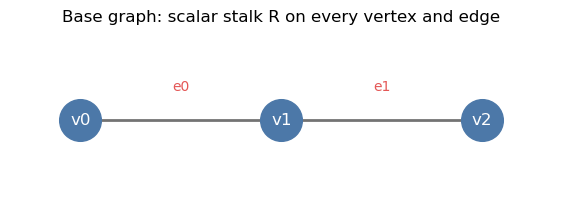

In [2]:
vertices = ('v0', 'v1', 'v2')
edges = (('v0', 'v1'), ('v1', 'v2'))

# Rows correspond to oriented edges; columns correspond to vertices.
delta = np.array([
    [-1.0,  1.0,  0.0],
    [ 0.0, -1.0,  1.0],
])
L = delta.T @ delta

print('Coboundary delta:')
print(delta)
print('\nSheaf Laplacian L = delta.T @ delta:')
print(L)

fig, ax = plt.subplots(figsize=(7, 2.2))
positions = np.array([[0.0, 0.0], [1.0, 0.0], [2.0, 0.0]])
ax.plot(positions[:, 0], positions[:, 1], color='0.45', linewidth=2, zorder=1)
ax.scatter(positions[:, 0], positions[:, 1], s=900, color='#4C78A8', zorder=2)
for (x_pos, y_pos), label in zip(positions, vertices):
    ax.text(x_pos, y_pos, label, ha='center', va='center', color='white', fontsize=12)
for edge_index, midpoint in enumerate((0.5, 1.5)):
    ax.text(midpoint, 0.13, f'e{edge_index}', ha='center', color='#E45756')
ax.set(xlim=(-0.35, 2.35), ylim=(-0.35, 0.4), title='Base graph: scalar stalk R on every vertex and edge')
ax.axis('off')
plt.show()

## 2. Compatibility, energy, and global sections

A vertex assignment $x=(x_0,x_1,x_2)$ is a global section when every overlap agrees, so $\delta x=0$. The constant assignment is compatible; a nonconstant assignment is not.

The total disagreement energy has two equivalent forms:

$$
E(x)=\lVert\delta x\rVert_2^2=x^\top L_{\mathcal F}x.
$$

Because $L_{\mathcal F}=\delta^\top\delta$, it is symmetric positive semidefinite. Its zero-eigenvalue eigenvectors are precisely the global sections in this example.

In [3]:
x_global = np.array([1.0, 1.0, 1.0])
x_inconsistent = np.array([1.0, -0.5, 0.8])

def consistency_energy(x):
    return float(np.linalg.norm(delta @ x) ** 2)

eigenvalues = np.linalg.eigvalsh(L)

print(f'delta @ global section: {delta @ x_global}')
print(f'delta @ inconsistent assignment: {delta @ x_inconsistent}')
print(f'inconsistent energy: {consistency_energy(x_inconsistent):.3f}')
print(f'Laplacian eigenvalues: {eigenvalues}')

assert delta.shape == (2, 3)
assert L.shape == (3, 3)
assert np.allclose(L, L.T)
assert np.all(eigenvalues >= -1e-12)
assert np.count_nonzero(np.isclose(eigenvalues, 0.0, atol=1e-12)) == 1
assert np.allclose(delta @ x_global, 0.0)
assert np.isclose(consistency_energy(x_inconsistent), x_inconsistent @ L @ x_inconsistent)

delta @ global section: [0. 0.]
delta @ inconsistent assignment: [-1.5  1.3]
inconsistent energy: 3.940
Laplacian eigenvalues: [3.92505363e-17 1.00000000e+00 3.00000000e+00]


## 3. Diffusion is not the same as restoration

The update $x_{t+1}=x_t-\alpha L_{\mathcal F}x_t$ decreases disagreement when the step size is stable. With this connected identity sheaf, however, pure diffusion ultimately keeps only the mean of the initial observations. It has no term requiring the result to explain trusted measurements.

For restoration, add data fidelity and confidence. Let $y$ be the measurements and $W=\operatorname{diag}(w_i)$ their confidence matrix. We solve

$$
\hat x=\arg\min_x (x-y)^\top W(x-y)+\lambda x^\top L_{\mathcal F}x,
$$

whose unique solution for positive confidence is

$$
(W+\lambda L_{\mathcal F})\hat x=Wy.
$$

In [4]:
truth = np.ones(3)
observed = np.array([1.05, -0.80, 0.90])  # The center measurement is corrupted.
confidence = np.array([1.0, 0.03, 1.0])
W = np.diag(confidence)
regularization = 1.0

weighted_solution = np.linalg.solve(W + regularization * L, W @ observed)
unweighted_solution = np.linalg.solve(np.eye(3) + regularization * L, observed)

alpha = 0.25  # Stable because alpha < 2 / largest_eigenvalue(L).
diffused = observed.copy()
diffusion_history = [diffused.copy()]
for _ in range(40):
    diffused = diffused - alpha * (L @ diffused)
    diffusion_history.append(diffused.copy())
diffusion_history = np.asarray(diffusion_history)

def weighted_data_error(x):
    residual = x - observed
    return float(residual @ W @ residual)

print(f'truth:               {truth}')
print(f'observed:            {observed}')
print(f'pure diffusion:      {diffused.round(4)}')
print(f'unweighted solution: {unweighted_solution.round(4)}')
print(f'weighted solution:   {weighted_solution.round(4)}')
print()
print(f'observed consistency energy: {consistency_energy(observed):.4f}')
print(f'weighted consistency energy: {consistency_energy(weighted_solution):.4f}')
print(f'weighted data error:          {weighted_data_error(weighted_solution):.4f}')

assert np.all(np.isfinite(weighted_solution))
assert consistency_energy(diffused) < consistency_energy(observed)
assert consistency_energy(weighted_solution) < consistency_energy(observed)
assert np.linalg.norm(weighted_solution - truth) < np.linalg.norm(observed - truth)

truth:               [1. 1. 1.]
observed:            [ 1.05 -0.8   0.9 ]
pure diffusion:      [0.3833 0.3833 0.3833]
unweighted solution: [0.5688 0.0875 0.4938]
weighted solution:   [0.9867 0.9233 0.9117]

observed consistency energy: 6.3125
weighted consistency energy: 0.0041
weighted data error:          0.0932


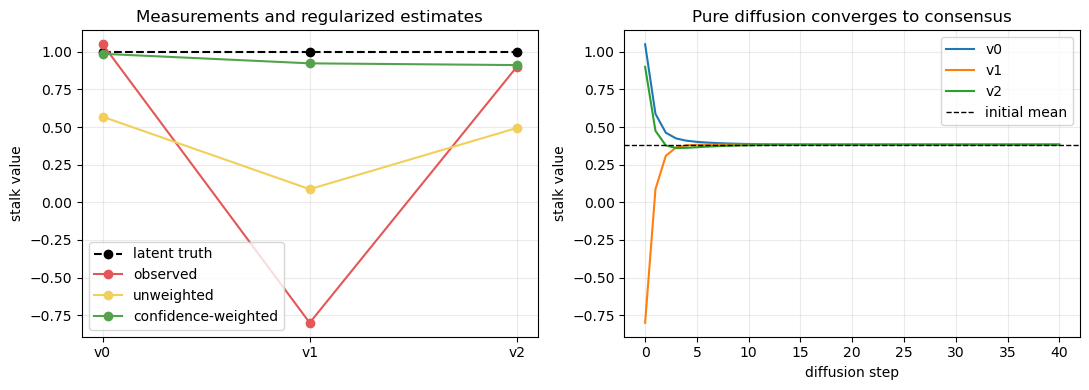

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

module_index = np.arange(3)
axes[0].plot(module_index, truth, 'k--', marker='o', label='latent truth')
axes[0].plot(module_index, observed, color='#E45756', marker='o', label='observed')
axes[0].plot(module_index, unweighted_solution, color='#F2CF5B', marker='o', label='unweighted')
axes[0].plot(module_index, weighted_solution, color='#54A24B', marker='o', label='confidence-weighted')
axes[0].set(xticks=module_index, xticklabels=vertices, ylabel='stalk value', title='Measurements and regularized estimates')
axes[0].legend()
axes[0].grid(alpha=0.25)

for vertex_index, vertex in enumerate(vertices):
    axes[1].plot(diffusion_history[:, vertex_index], label=vertex)
axes[1].axhline(observed.mean(), color='k', linestyle='--', linewidth=1, label='initial mean')
axes[1].set(xlabel='diffusion step', ylabel='stalk value', title='Pure diffusion converges to consensus')
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

## 4. What this teaches—and what it does not

We now have the complete linear cellular-sheaf pipeline in miniature:

1. the graph says which local data interact;
2. stalks say what data live at each graph cell;
3. restriction maps say what neighboring data must agree about;
4. $\delta$ measures every local disagreement;
5. $L_{\mathcal F}$ aggregates those disagreements;
6. confidence-weighted regularization balances agreement with evidence.

The restriction maps are the modeling decision. Identity maps on scalar stalks demand equality everywhere, which is useful for learning consensus but wrong for a barcode: neighboring barcode modules are allowed to differ. The next gate should use vector stalks for overlapping windows and coordinate-selection restriction maps. Those maps will require agreement only where two windows describe the same underlying module.

Gate 1 intentionally stops here. Gate 2 begins below only after review.

### Reference

Jakob Hansen and Robert Ghrist, [*Toward a Spectral Theory of Cellular Sheaves*](https://arxiv.org/abs/1808.01513).

# Gate 2: overlapping vector stalks

The scalar example required every neighboring value to be equal. That would erase a barcode's intentional black/white transitions. We now attach a **four-module vector** to each node instead. Neighboring windows advance by two modules, so they overlap on exactly two physical modules.

```text
global modules:  0 1 2 3 4 5 6 7
window 0:        [-------]
window 1:            [-------]
window 2:                [-------]
```

For an edge joining two consecutive windows, the left restriction map selects the last two coordinates of the earlier window and the right restriction map selects the first two coordinates of the later window. Only those descriptions of the **same physical modules** must agree. Values at different module positions remain free to differ.

> Scope boundary: the sequence is straight and module-aligned. This gate introduces no blur model, sensor noise, multiple scanlines, or unknown geometry.

In [6]:
binary_truth = np.array([1., 1., 0., 1., 0., 0., 1., 0.])
window_width = 4
stride = 2
overlap_width = window_width - stride
window_starts = np.arange(0, len(binary_truth) - window_width + 1, stride)
true_windows = np.stack([
    binary_truth[start:start + window_width]
    for start in window_starts
])

def coordinate_selector(indices, source_width):
    selector = np.zeros((len(indices), source_width))
    selector[np.arange(len(indices)), indices] = 1.0
    return selector

restrict_left = coordinate_selector(
    np.arange(window_width - overlap_width, window_width),
    window_width,
)
restrict_right = coordinate_selector(np.arange(overlap_width), window_width)

number_of_windows = len(true_windows)
number_of_edges = number_of_windows - 1
delta_windows = np.zeros((
    number_of_edges * overlap_width,
    number_of_windows * window_width,
))

for edge_index in range(number_of_edges):
    row = slice(edge_index * overlap_width, (edge_index + 1) * overlap_width)
    left = slice(edge_index * window_width, (edge_index + 1) * window_width)
    right = slice((edge_index + 1) * window_width, (edge_index + 2) * window_width)
    delta_windows[row, left] = -restrict_left
    delta_windows[row, right] = restrict_right

L_windows = delta_windows.T @ delta_windows
stacked_truth = true_windows.reshape(-1)
window_eigenvalues = np.linalg.eigvalsh(L_windows)
window_rank = np.linalg.matrix_rank(delta_windows)
kernel_dimension = L_windows.shape[0] - window_rank

print(f'global truth: {binary_truth.astype(int)}')
print('local window stalks:')
print(true_windows.astype(int))
print(f'coboundary shape: {delta_windows.shape}')
print(delta_windows)
print(f'delta @ stacked truth: {delta_windows @ stacked_truth}')
print(f'rank(delta): {window_rank}')
print(f'dimension of global-section space: {kernel_dimension}')

assert true_windows.shape == (3, 4)
assert delta_windows.shape == (4, 12)
assert np.allclose(delta_windows @ stacked_truth, 0.0)
assert np.allclose(L_windows, L_windows.T)
assert np.all(window_eigenvalues >= -1e-12)
assert kernel_dimension == len(binary_truth)

global truth: [1 1 0 1 0 0 1 0]
local window stalks:
[[1 1 0 1]
 [0 1 0 0]
 [0 0 1 0]]
coboundary shape: (4, 12)
[[-0. -0. -1. -0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [-0. -0. -0. -1.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -0. -0. -1. -0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0. -0. -0. -0. -1.  0.  1.  0.  0.]]
delta @ stacked truth: [0. 0. 0. 0.]
rank(delta): 4
dimension of global-section space: 8


## Why barcode transitions survive

The local state contains $3\times4=12$ values. Four independent overlap equations identify duplicate descriptions, leaving an eight-dimensional global-section space—the same dimension as the eight-module global sequence.

This is the key change from Gate 1. The kernel no longer contains only constant signals. It contains every globally defined eight-module sequence represented consistently by the three windows, including sequences with arbitrary transitions between black and white. The sheaf enforces **same module, same value**, not **neighboring module, same value**.

In [7]:
observed_windows = true_windows.copy()
observed_windows[1, 0] = 1.0  # Contradicts window 0 about global module 2.
confidence_windows = np.ones_like(observed_windows)
confidence_windows[1, 0] = 0.03  # This local value is known to be unreliable.

observed_stalks = observed_windows.reshape(-1)
confidence_stalks = confidence_windows.reshape(-1)
W_windows = np.diag(confidence_stalks)
overlap_regularization = 3.0
restored_stalks = np.linalg.solve(
    W_windows + overlap_regularization * L_windows,
    W_windows @ observed_stalks,
)
restored_windows = restored_stalks.reshape(number_of_windows, window_width)

def overlap_residuals(stalk_values):
    return (delta_windows @ np.asarray(stalk_values).reshape(-1)).reshape(
        number_of_edges, overlap_width
    )

def glue_windows(window_values):
    totals = np.zeros(len(binary_truth))
    counts = np.zeros(len(binary_truth))
    for start, values in zip(window_starts, window_values):
        totals[start:start + window_width] += values
        counts[start:start + window_width] += 1
    return totals / counts

observed_residuals = overlap_residuals(observed_stalks)
restored_residuals = overlap_residuals(restored_stalks)
glued_restoration = glue_windows(restored_windows)
restored_bits = (glued_restoration >= 0.5).astype(int)

print('observed windows:')
print(observed_windows)
print('\noverlap disagreements before restoration:')
print(observed_residuals)
print('\nrestored windows:')
print(restored_windows.round(4))
print('\noverlap disagreements after restoration:')
print(restored_residuals.round(4))
print(f'\nglued continuous sequence: {glued_restoration.round(4)}')
print(f'thresholded sequence:      {restored_bits}')

assert np.linalg.norm(restored_residuals) < np.linalg.norm(observed_residuals)
assert abs(restored_windows[1, 0] - binary_truth[2]) < abs(observed_windows[1, 0] - binary_truth[2])
assert np.array_equal(restored_bits, binary_truth.astype(int))
assert np.any(np.diff(restored_bits) != 0), 'Real barcode transitions must survive.'

observed windows:
[[1. 1. 0. 1.]
 [1. 1. 0. 0.]
 [0. 0. 1. 0.]]

overlap disagreements before restoration:
[[1. 0.]
 [0. 0.]]

restored windows:
[[1.     1.     0.0288 1.    ]
 [0.0385 1.     0.     0.    ]
 [0.     0.     1.     0.    ]]

overlap disagreements after restoration:
[[0.0096 0.    ]
 [0.     0.    ]]

glued continuous sequence: [1.     1.     0.0337 1.     0.     0.     1.     0.    ]
thresholded sequence:      [1 1 0 1 0 0 1 0]


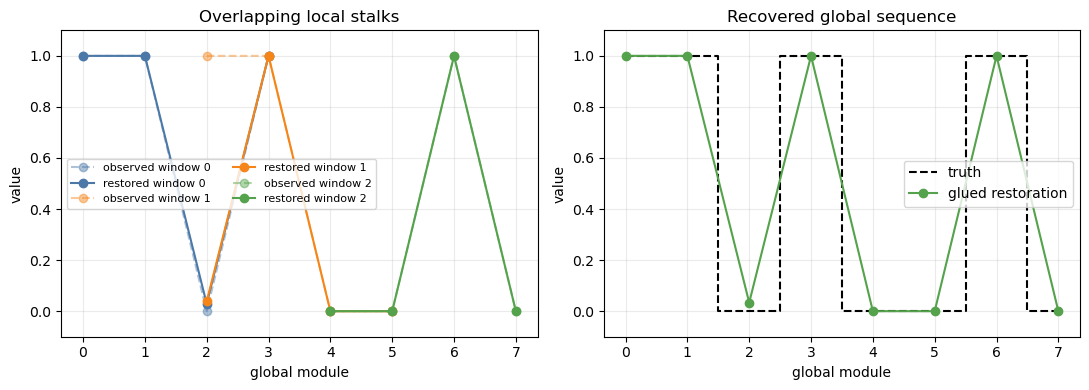

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ('#4C78A8', '#F58518', '#54A24B')
for window_index, (start, color) in enumerate(zip(window_starts, colors)):
    global_positions = np.arange(start, start + window_width)
    axes[0].plot(
        global_positions, observed_windows[window_index], 'o--',
        color=color, alpha=0.45, label=f'observed window {window_index}',
    )
    axes[0].plot(
        global_positions, restored_windows[window_index], 'o-',
        color=color, label=f'restored window {window_index}',
    )
axes[0].set(xticks=np.arange(len(binary_truth)), ylim=(-0.1, 1.1), xlabel='global module', ylabel='value', title='Overlapping local stalks')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncol=2)

axes[1].step(np.arange(len(binary_truth)), binary_truth, where='mid', color='k', linestyle='--', label='truth')
axes[1].plot(np.arange(len(binary_truth)), glued_restoration, 'o-', color='#54A24B', label='glued restoration')
axes[1].set(xticks=np.arange(len(binary_truth)), ylim=(-0.1, 1.1), xlabel='global module', ylabel='value', title='Recovered global sequence')
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

## Gate 2 conclusion and checkpoint

Vector stalks and coordinate-selection restriction maps solve the conceptual problem exposed by Gate 1: the sheaf can preserve arbitrary barcode transitions while detecting contradictions only where local windows describe the same physical module. Confidence-weighted regularization can pull an unreliable local copy toward a trusted overlapping copy.

This is still a consistency experiment, not a camera model. The windows are perfectly aligned and their module coordinates are known. The next gate, only after review, is fixed multi-scanline fusion with a controlled damaged region. Blur, unknown module alignment, adaptive direction, and symbology decoding remain later work.

Gate 2 intentionally stops here. Gate 3 begins below only after review.

# Gate 3: fixed multi-scanline fusion

We now copy the straight, aligned barcode across three scanlines. Every scanline is divided into the same three overlapping four-module windows used in Gate 2. The node graph is therefore a small grid:

```text
scanline 0:  w00 -- w01 -- w02
               |      |      |
scanline 1:  w10 -- w11 -- w12
               |      |      |
scanline 2:  w20 -- w21 -- w22
```

Horizontal edges use the Gate 2 coordinate selectors and compare only the two shared modules. Vertical edges connect the same window position on adjacent scanlines; because alignment is known, their restriction maps are the four-dimensional identity.

A controlled damaged region flips modules 2–4 in the middle scanline. Those measurements receive low confidence, allowing the two clear scanlines and overlap constraints to correct them. The graph does not literally route data along a chosen path: its cycles provide redundant constraints through undamaged neighboring nodes.

> Scope boundary: there is no Gaussian blur, random sensor noise, uncertain confidence estimation, or geometric misalignment in this gate.

In [9]:
number_of_scanlines = 3
windows_per_scanline = number_of_windows
node_count = number_of_scanlines * windows_per_scanline
values_per_node = window_width
variable_count = node_count * values_per_node

horizontal_edge_count = number_of_scanlines * (windows_per_scanline - 1)
vertical_edge_count = (number_of_scanlines - 1) * windows_per_scanline
horizontal_row_count = horizontal_edge_count * overlap_width
vertical_row_count = vertical_edge_count * window_width
delta_multiscan = np.zeros((horizontal_row_count + vertical_row_count, variable_count))

def node_slice(scanline_index, window_index):
    node_index = scanline_index * windows_per_scanline + window_index
    start = node_index * values_per_node
    return slice(start, start + values_per_node)

row_cursor = 0
for scanline_index in range(number_of_scanlines):
    for window_index in range(windows_per_scanline - 1):
        rows = slice(row_cursor, row_cursor + overlap_width)
        delta_multiscan[rows, node_slice(scanline_index, window_index)] = -restrict_left
        delta_multiscan[rows, node_slice(scanline_index, window_index + 1)] = restrict_right
        row_cursor += overlap_width

identity_restriction = np.eye(window_width)
for scanline_index in range(number_of_scanlines - 1):
    for window_index in range(windows_per_scanline):
        rows = slice(row_cursor, row_cursor + window_width)
        delta_multiscan[rows, node_slice(scanline_index, window_index)] = -identity_restriction
        delta_multiscan[rows, node_slice(scanline_index + 1, window_index)] = identity_restriction
        row_cursor += window_width

L_multiscan = delta_multiscan.T @ delta_multiscan
clean_scanlines = np.tile(binary_truth, (number_of_scanlines, 1))
true_window_grid = np.stack([
    np.stack([row[start:start + window_width] for start in window_starts])
    for row in clean_scanlines
])
stacked_multiscan_truth = true_window_grid.reshape(-1)
multiscan_rank = np.linalg.matrix_rank(delta_multiscan)
multiscan_kernel_dimension = variable_count - multiscan_rank
multiscan_eigenvalues = np.linalg.eigvalsh(L_multiscan)

print(f'nodes: {node_count} = {number_of_scanlines} scanlines x {windows_per_scanline} windows')
print(f'variables: {variable_count} = {node_count} nodes x {values_per_node} values')
print(f'horizontal edges: {horizontal_edge_count}, contributing {horizontal_row_count} comparisons')
print(f'vertical edges: {vertical_edge_count}, contributing {vertical_row_count} comparisons')
print(f'coboundary shape: {delta_multiscan.shape}')
print(f'rank(delta): {multiscan_rank}')
print(f'dimension of global-section space: {multiscan_kernel_dimension}')
print(f'maximum truth disagreement: {np.abs(delta_multiscan @ stacked_multiscan_truth).max():.1f}')

assert row_cursor == delta_multiscan.shape[0]
assert delta_multiscan.shape == (36, 36)
assert np.allclose(delta_multiscan @ stacked_multiscan_truth, 0.0)
assert np.allclose(L_multiscan, L_multiscan.T)
assert np.all(multiscan_eigenvalues >= -1e-12)
assert multiscan_kernel_dimension == len(binary_truth)

nodes: 9 = 3 scanlines x 3 windows
variables: 36 = 9 nodes x 4 values
horizontal edges: 6, contributing 12 comparisons
vertical edges: 6, contributing 24 comparisons
coboundary shape: (36, 36)
rank(delta): 28
dimension of global-section space: 8
maximum truth disagreement: 0.0


## What the larger coboundary represents

There are $9\times4=36$ locally stored values. The coboundary also has 36 rows: 12 horizontal overlap comparisons and 24 vertical cross-scanline comparisons. Some equations are redundant because the grid contains cycles, so the matrix rank is 28 rather than 36. Its kernel still has dimension $36-28=8$: a compatible assignment is determined by one arbitrary eight-module global sequence copied consistently into every overlapping window and scanline.

This is the algebraic version of redundant evidence. A value in the damaged middle row is constrained horizontally by its window overlaps and vertically by corresponding clear windows above and below.

In [10]:
observed_scanlines = clean_scanlines.copy()
damaged_scanline_index = 1
damaged_modules = np.arange(2, 5)
observed_scanlines[damaged_scanline_index, damaged_modules] = (
    1.0 - observed_scanlines[damaged_scanline_index, damaged_modules]
)

scanline_confidence = np.ones_like(observed_scanlines)
scanline_confidence[damaged_scanline_index, damaged_modules] = 0.02

def windowize_scanlines(scanline_values):
    return np.stack([
        np.stack([row[start:start + window_width] for start in window_starts])
        for row in scanline_values
    ])

observed_window_grid = windowize_scanlines(observed_scanlines)
confidence_window_grid = windowize_scanlines(scanline_confidence)
observed_multiscan_stalks = observed_window_grid.reshape(-1)
confidence_multiscan_stalks = confidence_window_grid.reshape(-1)
W_multiscan = np.diag(confidence_multiscan_stalks)
multiscan_regularization = 2.0
restored_multiscan_stalks = np.linalg.solve(
    W_multiscan + multiscan_regularization * L_multiscan,
    W_multiscan @ observed_multiscan_stalks,
)
restored_window_grid = restored_multiscan_stalks.reshape(
    number_of_scanlines, windows_per_scanline, window_width
)
restored_scanlines = np.stack([
    glue_windows(restored_window_grid[scanline_index])
    for scanline_index in range(number_of_scanlines)
])
fused_restoration = restored_scanlines.mean(axis=0)
restored_multiscan_bits = (fused_restoration >= 0.5).astype(int)

plain_mean = observed_scanlines.mean(axis=0)
confidence_mean = (scanline_confidence * observed_scanlines).sum(axis=0) / scanline_confidence.sum(axis=0)
observed_energy = float(np.linalg.norm(delta_multiscan @ observed_multiscan_stalks) ** 2)
restored_energy = float(np.linalg.norm(delta_multiscan @ restored_multiscan_stalks) ** 2)

print('observed scanlines:')
print(observed_scanlines.astype(int))
print('\nconfidence map:')
print(scanline_confidence)
print('\nrestored scanlines:')
print(restored_scanlines.round(4))
print(f'\nplain per-module mean:      {plain_mean.round(4)}')
print(f'confidence-weighted mean:  {confidence_mean.round(4)}')
print(f'sheaf fused restoration:  {fused_restoration.round(4)}')
print(f'sheaf thresholded result: {restored_multiscan_bits}')
print(f'\nconsistency energy: {observed_energy:.4f} -> {restored_energy:.6f}')

assert not np.array_equal(observed_scanlines[damaged_scanline_index].astype(int), binary_truth.astype(int))
assert restored_energy < observed_energy
assert np.array_equal(restored_multiscan_bits, binary_truth.astype(int))
assert np.linalg.norm(fused_restoration - binary_truth) < np.linalg.norm(plain_mean - binary_truth)

observed scanlines:
[[1 1 0 1 0 0 1 0]
 [1 1 1 0 1 0 1 0]
 [1 1 0 1 0 0 1 0]]

confidence map:
[[1.   1.   1.   1.   1.   1.   1.   1.  ]
 [1.   1.   0.02 0.02 0.02 1.   1.   1.  ]
 [1.   1.   1.   1.   1.   1.   1.   1.  ]]

restored scanlines:
[[1.     1.     0.0099 0.9901 0.0099 0.     1.     0.    ]
 [1.     1.     0.0148 0.9852 0.0148 0.     1.     0.    ]
 [1.     1.     0.0099 0.9901 0.0099 0.     1.     0.    ]]

plain per-module mean:      [1.     1.     0.3333 0.6667 0.3333 0.     1.     0.    ]
confidence-weighted mean:  [1.     1.     0.0099 0.9901 0.0099 0.     1.     0.    ]
sheaf fused restoration:  [1.     1.     0.0115 0.9885 0.0115 0.     1.     0.    ]
sheaf thresholded result: [1 1 0 1 0 0 1 0]

consistency energy: 12.0000 -> 0.000291


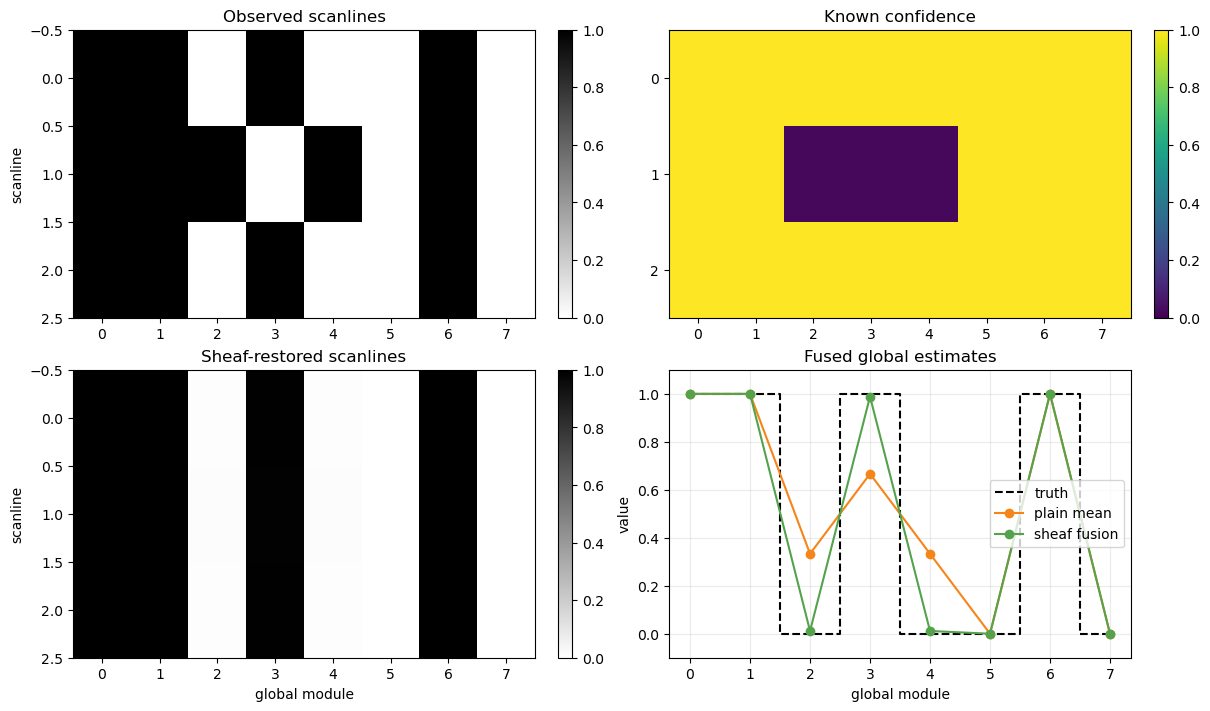

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

image_options = dict(aspect='auto', interpolation='nearest', vmin=0, vmax=1, cmap='gray_r')
observed_image = axes[0, 0].imshow(observed_scanlines, **image_options)
axes[0, 0].set(title='Observed scanlines', ylabel='scanline', xticks=np.arange(len(binary_truth)))
fig.colorbar(observed_image, ax=axes[0, 0], fraction=0.046)

confidence_image = axes[0, 1].imshow(scanline_confidence, aspect='auto', interpolation='nearest', vmin=0, vmax=1, cmap='viridis')
axes[0, 1].set(title='Known confidence', xticks=np.arange(len(binary_truth)), yticks=np.arange(number_of_scanlines))
fig.colorbar(confidence_image, ax=axes[0, 1], fraction=0.046)

restored_image = axes[1, 0].imshow(restored_scanlines, **image_options)
axes[1, 0].set(title='Sheaf-restored scanlines', xlabel='global module', ylabel='scanline', xticks=np.arange(len(binary_truth)))
fig.colorbar(restored_image, ax=axes[1, 0], fraction=0.046)

module_positions = np.arange(len(binary_truth))
axes[1, 1].step(module_positions, binary_truth, where='mid', color='k', linestyle='--', label='truth')
axes[1, 1].plot(module_positions, plain_mean, 'o-', color='#F58518', label='plain mean')
axes[1, 1].plot(module_positions, fused_restoration, 'o-', color='#54A24B', label='sheaf fusion')
axes[1, 1].set(title='Fused global estimates', xlabel='global module', ylabel='value', xticks=module_positions, ylim=(-0.1, 1.1))
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend()

plt.show()

## Gate 3 conclusion and checkpoint

The grid sheaf fuses redundant scanlines while retaining the overlap semantics from Gate 2. Low-confidence measurements in one local region are pulled toward compatible evidence above, below, left, and right. This is the first small demonstration of the proposed damage-recovery mechanism.

The comparison also matters: because every scanline is perfectly aligned and confidence is already known, a simple per-module confidence-weighted mean is a strong baseline and nearly solves this toy problem directly. The sheaf formulation must later justify itself when overlaps, local geometry, missing coverage, or decoder constraints make simple averaging insufficient.

Gate 3 intentionally stops here. Gate 4 begins below only after review.

# Gate 4: Gaussian blur and sensor noise

The previous gates treated each stalk value as a direct observation of one latent module. A camera instead measures a transformed signal: neighboring black and white modules blend through the optics, and the sensor adds noise. For each four-module node we now use

$$y_i = Hx_i + \varepsilon_i,$$

where $x_i$ is the latent local module vector, $H$ is a row-normalized Gaussian blur matrix, and $\varepsilon_i$ is seeded zero-mean Gaussian noise. The joint estimator becomes

$$
\hat x=\arg\min_x
\lVert W^{1/2}(Hx-y)\rVert^2
+\lambda\lVert\delta x\rVert^2
+\eta\lVert x\rVert^2.
$$

The first term explains the blurred measurements, the second enforces sheaf consistency among latent windows, and the small final Tikhonov term stabilizes deconvolution. The same stabilizer is used in the independent-deconvolution baseline.

> This remains a deliberately simplified **module-space** blur model. It does not yet render bars into pixels, estimate module pitch, or infer the optical point-spread function.

In [12]:
gate4_seed = SEED + 4
gate4_rng = np.random.default_rng(gate4_seed)
blur_sigma_modules = 1.0
sensor_noise_std = 0.10

local_coordinates = np.arange(window_width)
coordinate_distance = local_coordinates[:, None] - local_coordinates[None, :]
blur_matrix = np.exp(-(coordinate_distance ** 2) / (2 * blur_sigma_modules ** 2))
blur_matrix /= blur_matrix.sum(axis=1, keepdims=True)
H_multiscan = np.kron(np.eye(node_count), blur_matrix)

blurred_noiseless_stalks = H_multiscan @ stacked_multiscan_truth
gate4_observations = blurred_noiseless_stalks + gate4_rng.normal(
    0.0, sensor_noise_std, size=variable_count
)

# Retain the controlled low-confidence damaged region from Gate 3. It is
# saturated near gray rather than flipped after the optical blur is applied.
gate4_confidence = confidence_multiscan_stalks.copy()
gate4_damage_mask = gate4_confidence < 0.1
gate4_observations[gate4_damage_mask] = 0.5 + gate4_rng.normal(
    0.0, sensor_noise_std, size=np.count_nonzero(gate4_damage_mask)
)
gate4_observations = np.clip(gate4_observations, 0.0, 1.0)
gate4_observation_grid = gate4_observations.reshape(
    number_of_scanlines, windows_per_scanline, window_width
)
gate4_observed_scanlines = np.stack([
    glue_windows(gate4_observation_grid[scanline_index])
    for scanline_index in range(number_of_scanlines)
])

print(f'random seed: {gate4_seed}')
print(f'blur sigma: {blur_sigma_modules:.2f} modules')
print(f'sensor noise standard deviation: {sensor_noise_std:.2f}')
print('\nlocal Gaussian blur matrix H:')
print(blur_matrix.round(4))
print('\nglued blurred/noisy observations:')
print(gate4_observed_scanlines.round(4))

assert np.allclose(blur_matrix.sum(axis=1), 1.0)
assert H_multiscan.shape == (variable_count, variable_count)
assert np.all((gate4_observations >= 0.0) & (gate4_observations <= 1.0))
assert np.count_nonzero(gate4_damage_mask) > 0

random seed: 11
blur sigma: 1.00 modules
sensor noise standard deviation: 0.10

local Gaussian blur matrix H:
[[0.5705 0.346  0.0772 0.0063]
 [0.2583 0.4258 0.2583 0.0576]
 [0.0576 0.2583 0.4258 0.2583]
 [0.0063 0.0772 0.346  0.5705]]

glued blurred/noisy observations:
[[0.9262 0.8777 0.5064 0.488  0.2336 0.0726 0.5825 0.3364]
 [0.9908 0.7281 0.5169 0.5115 0.5298 0.1263 0.4653 0.2789]
 [0.7308 0.6603 0.3621 0.4821 0.1754 0.1753 0.4975 0.316 ]]


## Compare increasingly structured estimators

Four estimators use the same generated data:

1. **Raw mean:** glue local observations and average the three scanlines, without using confidence or $H$.
2. **Confidence mean:** downweight the known damaged region, but still ignore blur.
3. **Independent deconvolution:** use $H$, confidence, and the stabilizer, but do not connect any stalks with $\delta$.
4. **Joint sheaf deconvolution:** use the same observation model plus the multi-scanline consistency penalty.

This ablation distinguishes gains from confidence, gains from modeling blur, and gains from local-to-global consistency.

In [13]:
gate4_W = np.diag(gate4_confidence)
tikhonov_strength = 0.02
gate4_sheaf_strength = 2.0
identity_variables = np.eye(variable_count)
normal_data_matrix = H_multiscan.T @ gate4_W @ H_multiscan
normal_data_vector = H_multiscan.T @ gate4_W @ gate4_observations

independent_latent_stalks = np.linalg.solve(
    normal_data_matrix + tikhonov_strength * identity_variables,
    normal_data_vector,
)
sheaf_latent_stalks = np.linalg.solve(
    normal_data_matrix
    + gate4_sheaf_strength * L_multiscan
    + tikhonov_strength * identity_variables,
    normal_data_vector,
)

def glue_multiscan_stalks(stalk_values):
    window_grid = np.asarray(stalk_values).reshape(
        number_of_scanlines, windows_per_scanline, window_width
    )
    return np.stack([glue_windows(window_grid[row]) for row in range(number_of_scanlines)])

raw_mean_estimate = gate4_observed_scanlines.mean(axis=0)
confidence_mean_estimate = (
    scanline_confidence * gate4_observed_scanlines
).sum(axis=0) / scanline_confidence.sum(axis=0)
independent_scanline_estimates = glue_multiscan_stalks(independent_latent_stalks)
independent_estimate = independent_scanline_estimates.mean(axis=0)
sheaf_scanline_estimates = glue_multiscan_stalks(sheaf_latent_stalks)
sheaf_estimate = sheaf_scanline_estimates.mean(axis=0)

estimators = {
    'raw mean': raw_mean_estimate,
    'confidence mean': confidence_mean_estimate,
    'independent deconvolution': independent_estimate,
    'joint sheaf deconvolution': sheaf_estimate,
}

def restoration_metrics(estimate):
    estimate = np.asarray(estimate)
    decoded = (estimate >= 0.5).astype(int)
    rmse = float(np.sqrt(np.mean((estimate - binary_truth) ** 2)))
    bit_error_rate = float(np.mean(decoded != binary_truth.astype(int)))
    return rmse, bit_error_rate, decoded

print(f"{'estimator':28s} {'RMSE':>8s} {'BER':>8s}  thresholded modules")
print('-' * 70)
gate4_metrics = {}
for name, estimate in estimators.items():
    rmse, bit_error_rate, decoded = restoration_metrics(estimate)
    gate4_metrics[name] = (rmse, bit_error_rate, decoded)
    print(f'{name:28s} {rmse:8.4f} {bit_error_rate:8.4f}  {decoded}')

independent_consistency = float(np.linalg.norm(delta_multiscan @ independent_latent_stalks) ** 2)
sheaf_consistency = float(np.linalg.norm(delta_multiscan @ sheaf_latent_stalks) ** 2)
print(f'\nlatent consistency energy: independent={independent_consistency:.6f}, sheaf={sheaf_consistency:.6f}')
print(f'sheaf continuous estimate: {sheaf_estimate.round(4)}')

assert gate4_metrics['raw mean'][1] > 0.0
assert gate4_metrics['independent deconvolution'][1] > 0.0
assert gate4_metrics['joint sheaf deconvolution'][1] == 0.0
assert gate4_metrics['joint sheaf deconvolution'][0] < gate4_metrics['independent deconvolution'][0]
assert sheaf_consistency < independent_consistency

estimator                        RMSE      BER  thresholded modules
----------------------------------------------------------------------
raw mean                       0.3514   0.1250  [1 1 0 0 0 0 1 0]
confidence mean                0.3387   0.1250  [1 1 0 0 0 0 1 0]
independent deconvolution      0.2419   0.1250  [1 1 0 0 0 0 1 0]
joint sheaf deconvolution      0.1534   0.0000  [1 1 0 1 0 0 1 0]

latent consistency energy: independent=3.518205, sheaf=0.008264
sheaf continuous estimate: [0.8445 1.0508 0.141  0.7143 0.0763 0.0227 0.8078 0.1297]


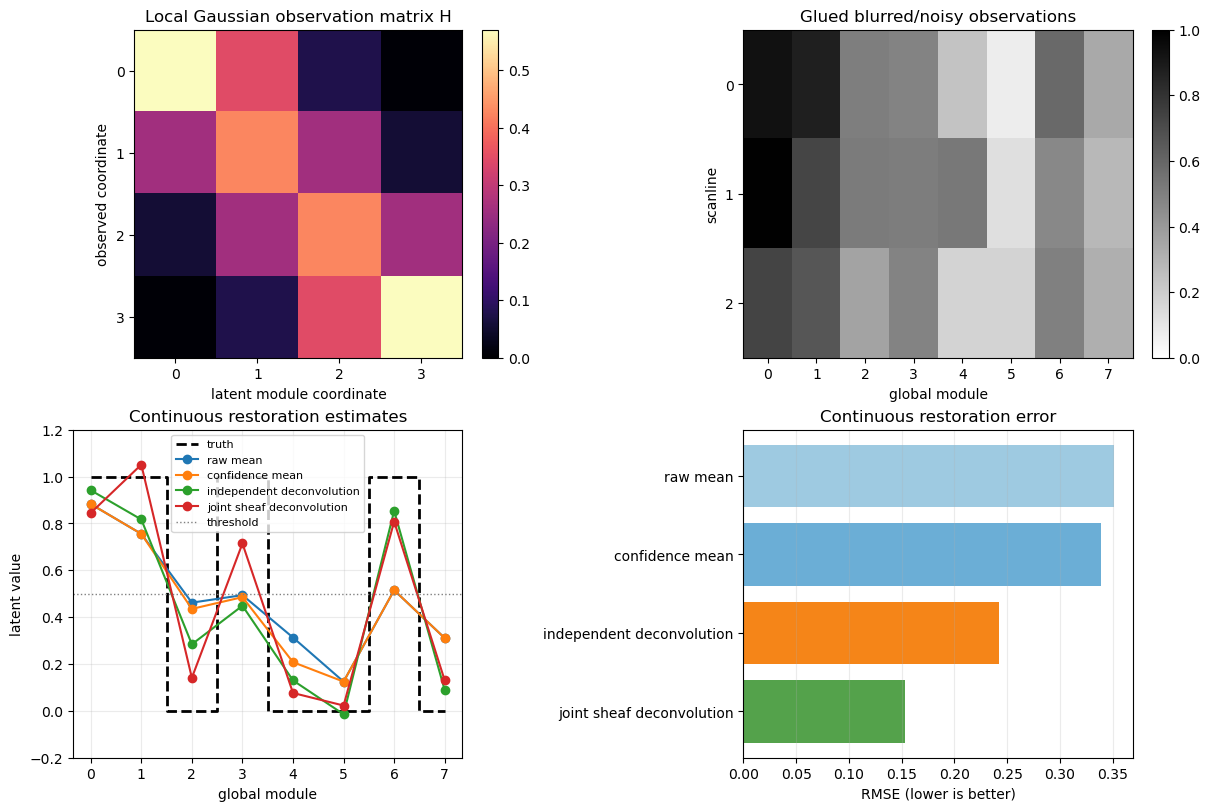

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

blur_image = axes[0, 0].imshow(blur_matrix, vmin=0, vmax=blur_matrix.max(), cmap='magma')
axes[0, 0].set(title='Local Gaussian observation matrix H', xlabel='latent module coordinate', ylabel='observed coordinate', xticks=np.arange(window_width), yticks=np.arange(window_width))
fig.colorbar(blur_image, ax=axes[0, 0], fraction=0.046)

observation_image = axes[0, 1].imshow(gate4_observed_scanlines, aspect='auto', interpolation='nearest', vmin=0, vmax=1, cmap='gray_r')
axes[0, 1].set(title='Glued blurred/noisy observations', xlabel='global module', ylabel='scanline', xticks=np.arange(len(binary_truth)), yticks=np.arange(number_of_scanlines))
fig.colorbar(observation_image, ax=axes[0, 1], fraction=0.046)

module_positions = np.arange(len(binary_truth))
axes[1, 0].step(module_positions, binary_truth, where='mid', color='k', linewidth=2, linestyle='--', label='truth')
for name, estimate in estimators.items():
    axes[1, 0].plot(module_positions, estimate, 'o-', label=name)
axes[1, 0].axhline(0.5, color='0.5', linewidth=1, linestyle=':', label='threshold')
axes[1, 0].set(title='Continuous restoration estimates', xlabel='global module', ylabel='latent value', xticks=module_positions, ylim=(-0.2, 1.2))
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(fontsize=8)

metric_names = list(estimators)
rmse_values = [gate4_metrics[name][0] for name in metric_names]
axes[1, 1].barh(metric_names, rmse_values, color=('#9ECAE1', '#6BAED6', '#F58518', '#54A24B'))
axes[1, 1].invert_yaxis()
axes[1, 1].set(title='Continuous restoration error', xlabel='RMSE (lower is better)')
axes[1, 1].grid(axis='x', alpha=0.25)

plt.show()

## Gate 4 conclusion and checkpoint

For this fixed seeded example, confidence alone is insufficient because it cannot undo optical mixing. Independent local deconvolution models the blur but amplifies ambiguity and does not reconcile duplicate latent modules. Adding sheaf consistency produces the lowest continuous error and the only exact thresholded sequence among the tested deconvolution variants.

This is evidence for the joint formulation, not yet a performance claim. It is one short hand-selected sequence, one blur level, one noise realization, oracle alignment, oracle confidence, and a known blur matrix. The unconstrained linear relaxation can also return values slightly outside $[0,1]$; a later estimator may need box constraints or calibrated probabilities.

Gate 4 intentionally stops here. Gate 5 begins below only after review.

# Gate 5: robustness and resource sweep

One successful example cannot establish robustness. This gate repeats the four-way ablation over randomly generated eight-module binary sequences and a small controlled grid of degradation settings:

- blur $\sigma\in\{0.0,0.6,1.0\}$ modules;
- sensor-noise standard deviation $\in\{0.0,0.08,0.16\}$;
- damaged middle-scanline width $\in\{0,1,3\}$ modules;
- 24 seeded trials per condition.

That gives $3\times3\times3\times24=648$ matched cases per estimator. Every method sees the same observation within a case. We record exact-sequence success, continuous RMSE, and wall-clock estimator time.

> These remain generic binary sequences rather than valid barcode symbols. Timings are Python/NumPy measurements on the current host, not embedded-device benchmarks.

In [15]:
from time import perf_counter_ns

gate5_seed = 29
gate5_rng = np.random.default_rng(gate5_seed)
gate5_trials_per_condition = 24
gate5_blur_levels = np.array([0.0, 0.6, 1.0])
gate5_noise_levels = np.array([0.0, 0.08, 0.16])
gate5_damage_widths = np.array([0, 1, 3])
gate5_method_names = (
    'raw mean',
    'confidence mean',
    'independent deconvolution',
    'joint sheaf deconvolution',
)

gate5_shape = (
    len(gate5_method_names),
    len(gate5_blur_levels),
    len(gate5_noise_levels),
    len(gate5_damage_widths),
    gate5_trials_per_condition,
)
gate5_success = np.zeros(gate5_shape, dtype=bool)
gate5_rmse = np.zeros(gate5_shape)
gate5_runtime_us = np.zeros(gate5_shape)
gate5_truths = np.zeros(gate5_shape[1:] + (len(binary_truth),))
gate5_observations = np.zeros(gate5_shape[1:] + (variable_count,))
gate5_estimates = np.zeros(gate5_shape + (len(binary_truth),))

def local_blur_for_sigma(sigma):
    if sigma == 0.0:
        return np.eye(window_width)
    distances = local_coordinates[:, None] - local_coordinates[None, :]
    matrix = np.exp(-(distances ** 2) / (2 * sigma ** 2))
    return matrix / matrix.sum(axis=1, keepdims=True)

def scanline_confidence_for_damage(damage_width):
    confidence = np.ones((number_of_scanlines, len(binary_truth)))
    if damage_width > 0:
        damage_start = (len(binary_truth) - damage_width) // 2
        confidence[damaged_scanline_index, damage_start:damage_start + damage_width] = 0.02
    return confidence

def random_nonconstant_binary_sequence(random_generator):
    sequence = random_generator.integers(0, 2, len(binary_truth)).astype(float)
    while np.all(sequence == sequence[0]):
        sequence = random_generator.integers(0, 2, len(binary_truth)).astype(float)
    return sequence

def store_gate5_result(method_index, indices, estimate, truth, elapsed_ns):
    result_index = (method_index,) + indices
    decoded = (estimate >= 0.5).astype(int)
    gate5_success[result_index] = np.array_equal(decoded, truth.astype(int))
    gate5_rmse[result_index] = np.sqrt(np.mean((estimate - truth) ** 2))
    gate5_runtime_us[result_index] = elapsed_ns / 1_000.0
    gate5_estimates[result_index] = estimate

for blur_index, blur_sigma in enumerate(gate5_blur_levels):
    local_H = local_blur_for_sigma(blur_sigma)
    full_H = np.kron(np.eye(node_count), local_H)

    for damage_index, damage_width in enumerate(gate5_damage_widths):
        global_confidence = scanline_confidence_for_damage(damage_width)
        local_confidence = windowize_scanlines(global_confidence).reshape(-1)
        confidence_matrix = np.diag(local_confidence)
        independent_matrix = (
            full_H.T @ confidence_matrix @ full_H
            + tikhonov_strength * identity_variables
        )
        sheaf_matrix = independent_matrix + gate4_sheaf_strength * L_multiscan
        damaged_local_coordinates = local_confidence < 0.1

        for noise_index, noise_std in enumerate(gate5_noise_levels):
            for trial_index in range(gate5_trials_per_condition):
                trial_truth = random_nonconstant_binary_sequence(gate5_rng)
                trial_scanlines = np.tile(trial_truth, (number_of_scanlines, 1))
                trial_latent_stalks = windowize_scanlines(trial_scanlines).reshape(-1)
                trial_observations = full_H @ trial_latent_stalks
                trial_observations += gate5_rng.normal(0.0, noise_std, variable_count)
                if np.any(damaged_local_coordinates):
                    trial_observations[damaged_local_coordinates] = 0.5 + gate5_rng.normal(
                        0.0, noise_std, np.count_nonzero(damaged_local_coordinates)
                    )
                trial_observations = np.clip(trial_observations, 0.0, 1.0)
                indices = (blur_index, noise_index, damage_index, trial_index)
                gate5_truths[indices] = trial_truth
                gate5_observations[indices] = trial_observations

                started = perf_counter_ns()
                trial_observed_scanlines = glue_multiscan_stalks(trial_observations)
                raw_estimate = trial_observed_scanlines.mean(axis=0)
                store_gate5_result(0, indices, raw_estimate, trial_truth, perf_counter_ns() - started)

                started = perf_counter_ns()
                trial_observed_scanlines = glue_multiscan_stalks(trial_observations)
                confidence_estimate = (
                    global_confidence * trial_observed_scanlines
                ).sum(axis=0) / global_confidence.sum(axis=0)
                store_gate5_result(1, indices, confidence_estimate, trial_truth, perf_counter_ns() - started)

                started = perf_counter_ns()
                trial_normal_vector = full_H.T @ (local_confidence * trial_observations)
                independent_stalks = np.linalg.solve(independent_matrix, trial_normal_vector)
                independent_estimate = glue_multiscan_stalks(independent_stalks).mean(axis=0)
                store_gate5_result(2, indices, independent_estimate, trial_truth, perf_counter_ns() - started)

                started = perf_counter_ns()
                trial_normal_vector = full_H.T @ (local_confidence * trial_observations)
                sheaf_stalks = np.linalg.solve(sheaf_matrix, trial_normal_vector)
                sheaf_trial_estimate = glue_multiscan_stalks(sheaf_stalks).mean(axis=0)
                store_gate5_result(3, indices, sheaf_trial_estimate, trial_truth, perf_counter_ns() - started)

gate5_case_count = int(np.prod(gate5_shape[1:]))
print(f'random seed: {gate5_seed}')
print(f'cases per estimator: {gate5_case_count}')
print(f'total estimator runs: {gate5_case_count * len(gate5_method_names)}')

assert gate5_case_count == 648
assert np.all(np.isfinite(gate5_rmse))
assert np.all(gate5_runtime_us > 0.0)

random seed: 29
cases per estimator: 648
total estimator runs: 2592


In [16]:
gate5_overall_success = gate5_success.mean(axis=(1, 2, 3, 4))
gate5_overall_rmse = gate5_rmse.mean(axis=(1, 2, 3, 4))
gate5_median_runtime_us = np.median(gate5_runtime_us, axis=(1, 2, 3, 4))
hardest_condition_success = gate5_success[:, -1, -1, -1, :].mean(axis=1)

print(f"{'estimator':28s} {'success':>9s} {'mean RMSE':>11s} {'median us':>11s} {'hardest':>9s}")
print('-' * 74)
for method_index, method_name in enumerate(gate5_method_names):
    print(
        f'{method_name:28s} '
        f'{gate5_overall_success[method_index]:9.3f} '
        f'{gate5_overall_rmse[method_index]:11.4f} '
        f'{gate5_median_runtime_us[method_index]:11.2f} '
        f'{hardest_condition_success[method_index]:9.3f}'
    )

assert gate5_overall_success[3] > gate5_overall_success[2]
assert gate5_overall_success[3] > gate5_overall_success[1]
assert gate5_overall_rmse[3] < gate5_overall_rmse[2]
assert hardest_condition_success[3] < 1.0, 'The sweep should expose a failure boundary.'

estimator                      success   mean RMSE   median us   hardest
--------------------------------------------------------------------------
raw mean                         0.801      0.1988       47.74     0.333
confidence mean                  0.806      0.1758       41.59     0.417
independent deconvolution        0.915      0.1434       69.80     0.542
joint sheaf deconvolution        0.983      0.0940       68.49     0.792


## Representative difficult cases

Aggregate rates can hide what an error looks like. For each degradation profile below, select the trial with the largest joint-sheaf RMSE among its 24 candidates. This is a deterministic diagnostic selection, not an additional experiment and not a random cherry-picked rerun. A profile's worst continuous case may still decode exactly; that distinction is printed explicitly.

In [17]:
gate5_diagnostic_profiles = (
    ('noise only', 0, 2, 0),
    ('blur only', 2, 0, 0),
    ('damage only', 0, 0, 2),
    ('blur + noise', 2, 2, 0),
    ('blur + noise + damage', 2, 2, 2),
)

def bit_string(values):
    return ''.join(str(value) for value in np.asarray(values, dtype=int))

gate5_selected_diagnostics = []
for profile_name, blur_index, noise_index, damage_index in gate5_diagnostic_profiles:
    trial_rmse = gate5_rmse[3, blur_index, noise_index, damage_index]
    trial_index = int(np.argmax(trial_rmse))
    indices = (blur_index, noise_index, damage_index, trial_index)
    truth = gate5_truths[indices]
    observations = glue_multiscan_stalks(gate5_observations[indices])
    gate5_selected_diagnostics.append((profile_name, indices))

    print('=' * 88)
    print(
        f'{profile_name.upper()} | blur sigma={gate5_blur_levels[blur_index]:.2f}, '
        f'noise std={gate5_noise_levels[noise_index]:.2f}, '
        f'damaged width={gate5_damage_widths[damage_index]}, trial={trial_index}'
    )
    print(f'truth: {bit_string(truth)}')
    print('glued observed scanlines:')
    print(observations.round(3))

    for method_index, method_name in enumerate(gate5_method_names):
        estimate = gate5_estimates[(method_index,) + indices]
        decoded = (estimate >= 0.5).astype(int)
        bit_errors = int(np.count_nonzero(decoded != truth.astype(int)))
        print(
            f'{method_name:28s} bits={bit_string(decoded)}  '
            f'errors={bit_errors}  RMSE={gate5_rmse[(method_index,) + indices]:.4f}  '
            f'estimate={np.round(estimate, 3)}'
        )
    print()

assert len(gate5_selected_diagnostics) == len(gate5_diagnostic_profiles)
assert len({indices for _, indices in gate5_selected_diagnostics}) == len(gate5_diagnostic_profiles)

NOISE ONLY | blur sigma=0.00, noise std=0.16, damaged width=0, trial=4
truth: 00011011
glued observed scanlines:
[[0.09  0.327 0.    0.928 0.953 0.163 0.734 1.   ]
 [0.    0.    0.034 1.    0.86  0.153 0.599 0.92 ]
 [0.045 0.215 0.029 0.976 0.911 0.201 1.    1.   ]]
raw mean                     bits=00011011  errors=0  RMSE=0.1248  estimate=[0.045 0.181 0.021 0.968 0.908 0.172 0.777 0.973]
confidence mean              bits=00011011  errors=0  RMSE=0.1248  estimate=[0.045 0.181 0.021 0.968 0.908 0.172 0.777 0.973]
independent deconvolution    bits=00011011  errors=0  RMSE=0.1302  estimate=[0.044 0.177 0.021 0.949 0.89  0.169 0.762 0.954]
joint sheaf deconvolution    bits=00011011  errors=0  RMSE=0.1302  estimate=[0.044 0.177 0.021 0.949 0.89  0.169 0.762 0.954]

BLUR ONLY | blur sigma=1.00, noise std=0.00, damaged width=0, trial=12
truth: 10101101
glued observed scanlines:
[[0.648 0.517 0.569 0.463 0.832 0.832 0.574 0.654]
 [0.648 0.517 0.569 0.463 0.832 0.832 0.574 0.654]
 [0.648 0.517

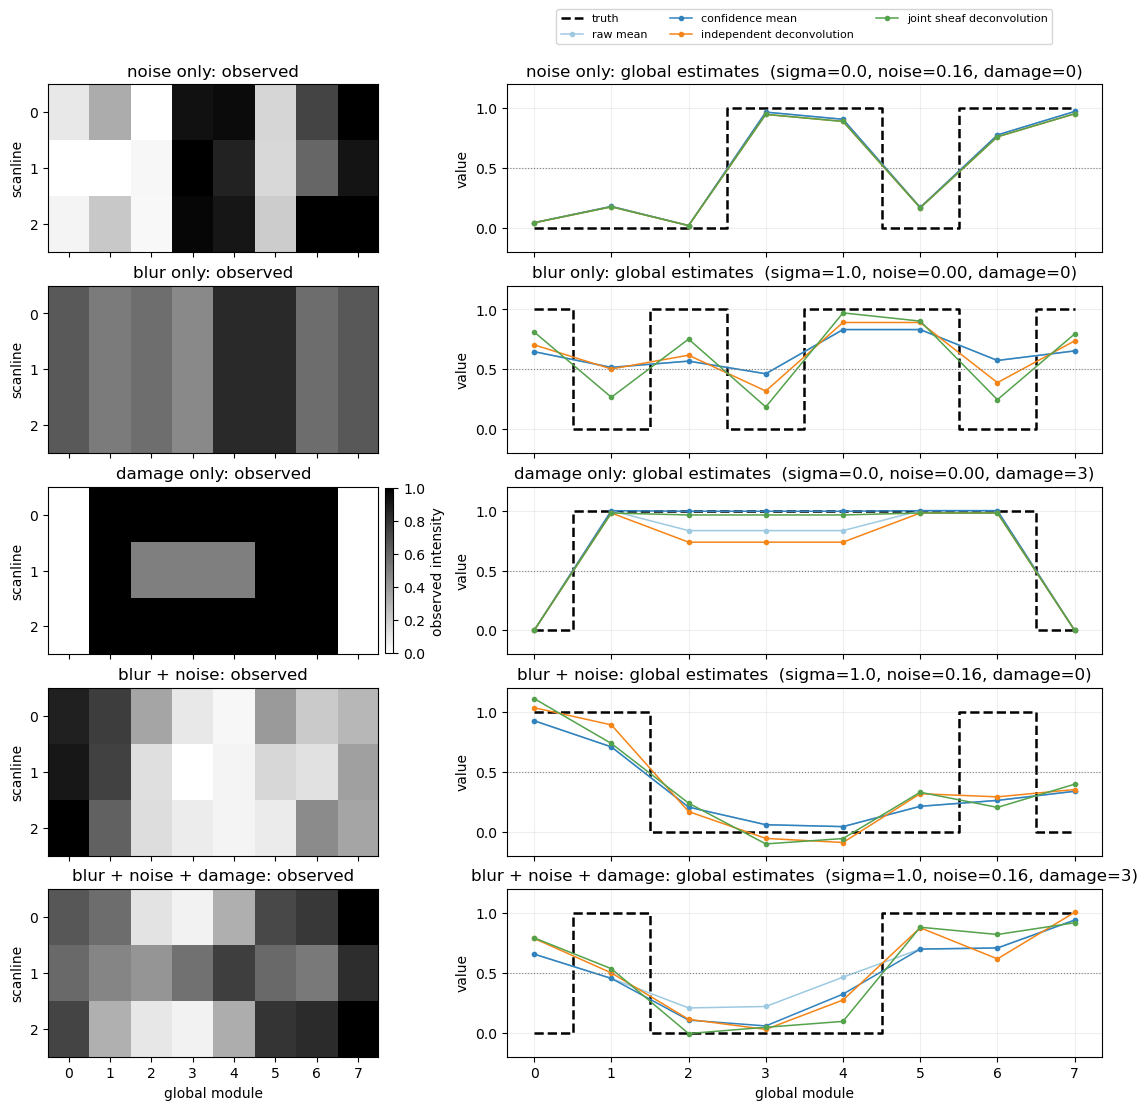

In [18]:
diagnostic_colors = ('#9ECAE1', '#3182BD', '#F58518', '#54A24B')
fig, axes = plt.subplots(
    len(gate5_selected_diagnostics), 2,
    figsize=(11, 11),
    sharex='col',
    constrained_layout=True,
    gridspec_kw={'width_ratios': (1.0, 1.8)},
)

for row_index, (profile_name, indices) in enumerate(gate5_selected_diagnostics):
    blur_index, noise_index, damage_index, trial_index = indices
    truth = gate5_truths[indices]
    observations = glue_multiscan_stalks(gate5_observations[indices])

    observed_ax = axes[row_index, 0]
    observed_image = observed_ax.imshow(
        observations, aspect='auto', interpolation='nearest',
        vmin=0, vmax=1, cmap='gray_r',
    )
    observed_ax.set(
        title=f'{profile_name}: observed',
        ylabel='scanline',
        yticks=np.arange(number_of_scanlines),
    )

    estimate_ax = axes[row_index, 1]
    estimate_ax.step(
        np.arange(len(binary_truth)), truth, where='mid',
        color='black', linewidth=1.8, linestyle='--', label='truth',
    )
    for method_index, (method_name, color) in enumerate(zip(gate5_method_names, diagnostic_colors)):
        estimate = gate5_estimates[(method_index,) + indices]
        estimate_ax.plot(
            np.arange(len(binary_truth)), estimate,
            marker='o', markersize=3, linewidth=1.1,
            color=color, label=method_name,
        )
    estimate_ax.axhline(0.5, color='0.5', linewidth=0.8, linestyle=':')
    estimate_ax.set(
        title=(
            f'{profile_name}: global estimates  '
            f'(sigma={gate5_blur_levels[blur_index]:.1f}, '
            f'noise={gate5_noise_levels[noise_index]:.2f}, '
            f'damage={gate5_damage_widths[damage_index]})'
        ),
        ylabel='value',
        ylim=(-0.2, 1.2),
        yticks=(0.0, 0.5, 1.0),
    )
    estimate_ax.grid(alpha=0.2)

axes[-1, 0].set(xlabel='global module', xticks=np.arange(len(binary_truth)))
axes[-1, 1].set(xlabel='global module', xticks=np.arange(len(binary_truth)))
axes[0, 1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.48), ncol=3, fontsize=8)
fig.colorbar(observed_image, ax=axes[:, 0], fraction=0.025, pad=0.02, label='observed intensity')
plt.show()

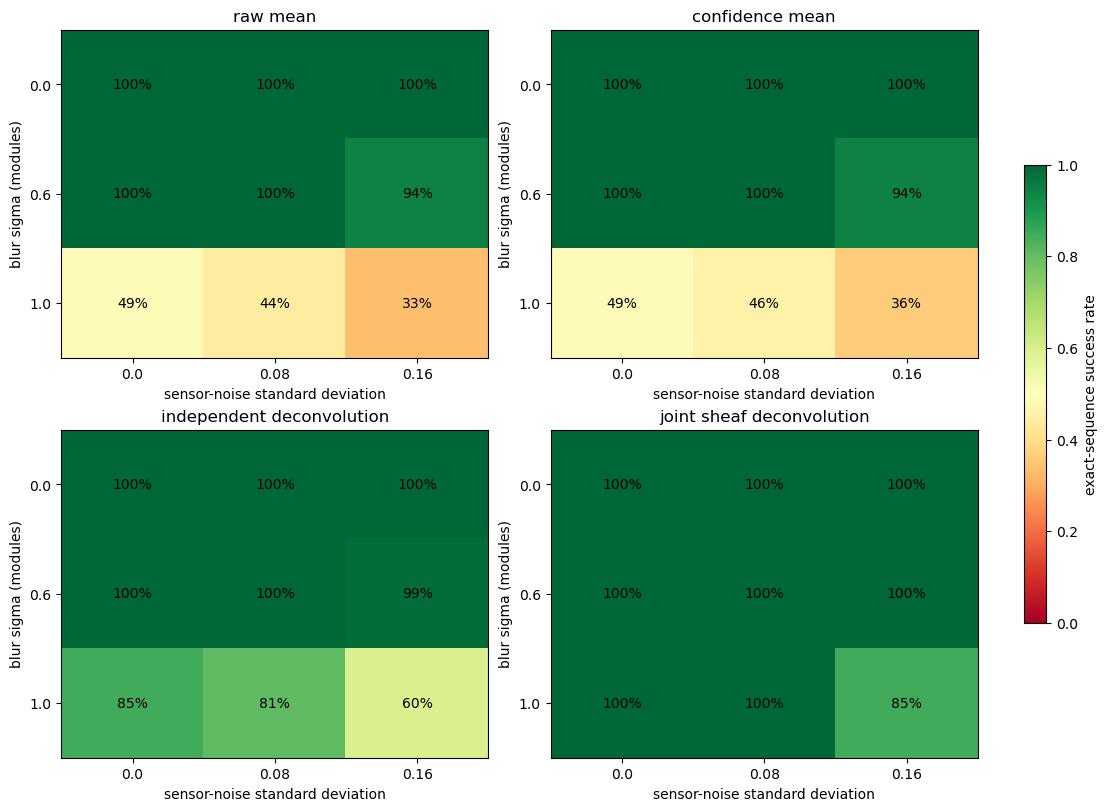

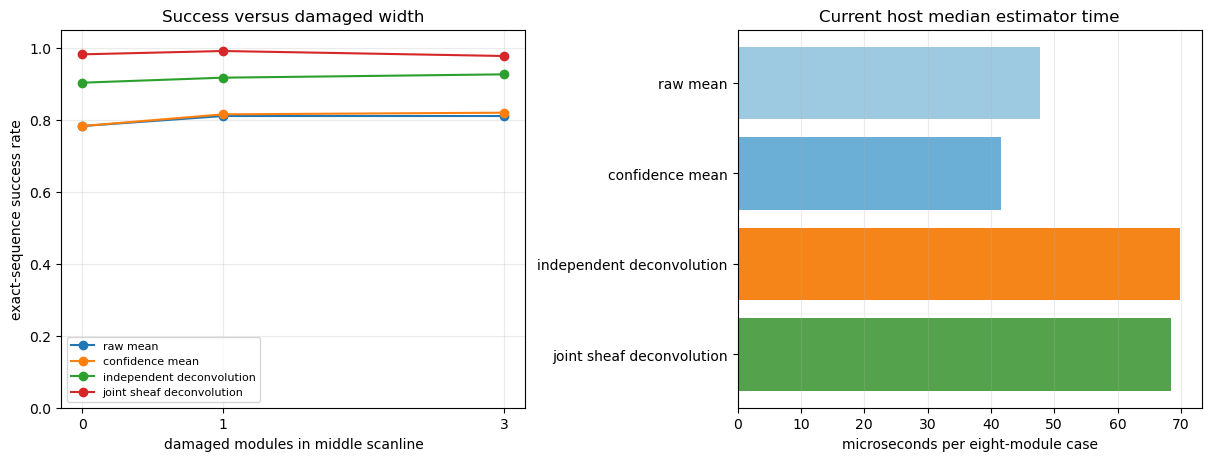

In [19]:
success_by_blur_noise = gate5_success.mean(axis=(3, 4))
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for method_index, (method_name, ax) in enumerate(zip(gate5_method_names, axes.flat)):
    values = success_by_blur_noise[method_index]
    image_handle = ax.imshow(values, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
    for blur_index in range(len(gate5_blur_levels)):
        for noise_index in range(len(gate5_noise_levels)):
            ax.text(noise_index, blur_index, f'{values[blur_index, noise_index]:.0%}', ha='center', va='center')
    ax.set(
        title=method_name,
        xlabel='sensor-noise standard deviation',
        ylabel='blur sigma (modules)',
        xticks=np.arange(len(gate5_noise_levels)),
        xticklabels=gate5_noise_levels,
        yticks=np.arange(len(gate5_blur_levels)),
        yticklabels=gate5_blur_levels,
    )
fig.colorbar(image_handle, ax=axes, fraction=0.025, label='exact-sequence success rate')
plt.show()

success_by_damage = gate5_success.mean(axis=(1, 2, 4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for method_index, method_name in enumerate(gate5_method_names):
    axes[0].plot(gate5_damage_widths, success_by_damage[method_index], 'o-', label=method_name)
axes[0].set(title='Success versus damaged width', xlabel='damaged modules in middle scanline', ylabel='exact-sequence success rate', xticks=gate5_damage_widths, ylim=(0, 1.05))
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].barh(gate5_method_names, gate5_median_runtime_us, color=('#9ECAE1', '#6BAED6', '#F58518', '#54A24B'))
axes[1].invert_yaxis()
axes[1].set(title='Current host median estimator time', xlabel='microseconds per eight-module case')
axes[1].grid(axis='x', alpha=0.25)
plt.show()

## Memory interpretation

The notebook intentionally uses transparent dense matrices and `numpy.linalg.solve`. That is appropriate for validating the mathematics but not for the proposed embedded implementation. The estimates below count dominant named arrays in the current reference formulation and exclude temporary LAPACK workspace, Python objects, the input image, and notebook outputs. They are therefore approximate lower bounds, not measured peak RAM.

In [20]:
float64_bytes = np.dtype(np.float64).itemsize
observation_vector_bytes = variable_count * float64_bytes
global_accumulator_bytes = 2 * len(binary_truth) * float64_bytes
dense_square_bytes = variable_count * variable_count * float64_bytes
three_solver_vectors_bytes = 3 * variable_count * float64_bytes

gate5_dense_memory_bytes = {
    'raw mean': observation_vector_bytes + global_accumulator_bytes,
    'confidence mean': 2 * observation_vector_bytes + global_accumulator_bytes,
    'independent deconvolution': (
        3 * dense_square_bytes + observation_vector_bytes + three_solver_vectors_bytes
    ),
    'joint sheaf deconvolution': (
        4 * dense_square_bytes + observation_vector_bytes + three_solver_vectors_bytes
    ),
}
matrix_free_float32_core_bytes = (5 * variable_count + window_width ** 2) * np.dtype(np.float32).itemsize

print('Approximate dominant-array memory in this dense float64 notebook:')
for method_name, byte_count in gate5_dense_memory_bytes.items():
    print(f'  {method_name:28s} {byte_count / 1024:7.2f} KiB')
print(
    f'\nIllustrative matrix-free float32 core: {matrix_free_float32_core_bytes} bytes '
    '(five state vectors plus one local 4x4 operator)'
)

assert gate5_dense_memory_bytes['joint sheaf deconvolution'] > gate5_dense_memory_bytes['independent deconvolution']
assert matrix_free_float32_core_bytes < 1024

Approximate dominant-array memory in this dense float64 notebook:
  raw mean                        0.41 KiB
  confidence mean                 0.69 KiB
  independent deconvolution      31.50 KiB
  joint sheaf deconvolution      41.62 KiB

Illustrative matrix-free float32 core: 784 bytes (five state vectors plus one local 4x4 operator)


## Gate 5 conclusion and checkpoint

This sweep replaces the single-example claim with a small empirical map. The important questions are whether the joint method improves exact recovery and continuous error overall, where all methods begin to fail, and how much latency the dense reference solve adds. The hardest condition is intentionally not required to succeed universally; exposing a failure boundary is more useful than tuning the experiment until it looks perfect.

The resource numbers also separate formulation from implementation. A dense direct solve is convenient research code. An embedded candidate would use implicit selector restrictions, local blur operators, reusable `float32` or tested fixed-point buffers, and a bounded matrix-free iteration. The sub-kilobyte figure is only an illustrative core-state estimate; it is not a complete decoder RAM measurement.

Gate 5 intentionally stops here. Gate 6 begins below only after review.

# Gate 6: bounded matrix-free solver

The dense reference computes and stores the complete normal matrix

$$A=H^\top WH+\lambda L_{\mathcal F}+\eta I$$

and solves $Ax=b$ with a generic factorization. An embedded implementation does not need any of those global matrices. Conjugate gradient only needs a function that returns $Av$ for a supplied vector $v$. We can apply each term locally:

- apply the same $4\times4$ blur operator independently at every node;
- multiply observations by the confidence vector directly;
- apply $H^\top$ locally;
- compute $L_{\mathcal F}v=\delta^\top\delta v$ by comparing and scattering horizontal and vertical edge disagreements;
- add the Tikhonov term elementwise.

This gate uses `float32` and a maximum budget of 24 CG updates. It stores no global $H$, $W$, $\delta$, $L_{\mathcal F}$, or $A$ inside the solver path.

In [21]:
def apply_local_observation(stalk_values, local_blur):
    grid = np.asarray(stalk_values).reshape(
        number_of_scanlines, windows_per_scanline, window_width
    )
    return np.einsum('ij,abj->abi', local_blur, grid).reshape(-1)

def apply_local_observation_transpose(observation_values, local_blur):
    grid = np.asarray(observation_values).reshape(
        number_of_scanlines, windows_per_scanline, window_width
    )
    return np.einsum('ji,abj->abi', local_blur, grid).reshape(-1)

def apply_local_sheaf_laplacian(stalk_values):
    values = np.asarray(stalk_values).reshape(
        number_of_scanlines, windows_per_scanline, window_width
    )
    result = np.zeros_like(values)

    for scanline_index in range(number_of_scanlines):
        for window_index in range(windows_per_scanline - 1):
            disagreement = (
                values[scanline_index, window_index + 1, :overlap_width]
                - values[scanline_index, window_index, -overlap_width:]
            )
            result[scanline_index, window_index, -overlap_width:] -= disagreement
            result[scanline_index, window_index + 1, :overlap_width] += disagreement

    for scanline_index in range(number_of_scanlines - 1):
        for window_index in range(windows_per_scanline):
            disagreement = (
                values[scanline_index + 1, window_index]
                - values[scanline_index, window_index]
            )
            result[scanline_index, window_index] -= disagreement
            result[scanline_index + 1, window_index] += disagreement

    return result.reshape(-1)

def make_matrix_free_normal_operator(
    local_blur, local_confidence, sheaf_strength, stabilizer_strength
):
    def apply_operator(stalk_values):
        blurred = apply_local_observation(stalk_values, local_blur)
        data_term = apply_local_observation_transpose(
            local_confidence * blurred, local_blur
        )
        return (
            data_term
            + sheaf_strength * apply_local_sheaf_laplacian(stalk_values)
            + stabilizer_strength * stalk_values
        )
    return apply_operator

# Prove that the local implementation applies the same operator as Gate 4's
# dense normal matrix before relying on it in the full sweep.
gate6_check_rng = np.random.default_rng(61)
gate6_check_vector = gate6_check_rng.normal(size=variable_count)
gate6_dense_operator = (
    normal_data_matrix
    + gate4_sheaf_strength * L_multiscan
    + tikhonov_strength * identity_variables
)
gate6_local_operator = make_matrix_free_normal_operator(
    blur_matrix, gate4_confidence, gate4_sheaf_strength, tikhonov_strength
)
gate6_operator_error = np.max(np.abs(
    gate6_local_operator(gate6_check_vector)
    - gate6_dense_operator @ gate6_check_vector
))
gate6_laplacian_error = np.max(np.abs(
    apply_local_sheaf_laplacian(gate6_check_vector)
    - L_multiscan @ gate6_check_vector
))
print(f'maximum Laplacian application error: {gate6_laplacian_error:.3e}')
print(f'maximum complete-operator error:     {gate6_operator_error:.3e}')

assert gate6_laplacian_error < 1e-12
assert gate6_operator_error < 1e-12

maximum Laplacian application error: 8.882e-16
maximum complete-operator error:     1.776e-15


In [22]:
def bounded_conjugate_gradient(apply_operator, right_hand_side, maximum_iterations):
    b = np.asarray(right_hand_side, dtype=np.float32)
    x = np.zeros_like(b)
    residual = b - apply_operator(x)
    direction = residual.copy()
    residual_squared = np.dot(residual, residual)
    initial_norm = max(float(np.sqrt(residual_squared)), np.finfo(np.float32).tiny)
    relative_residual_history = [1.0]
    iterations_used = 0

    for iteration in range(maximum_iterations):
        operator_direction = apply_operator(direction)
        denominator = float(np.dot(direction, operator_direction))
        if abs(denominator) <= np.finfo(np.float32).tiny:
            break
        step_size = float(residual_squared) / denominator
        x += step_size * direction
        residual -= step_size * operator_direction
        next_residual_squared = np.dot(residual, residual)
        relative_residual_history.append(
            float(np.sqrt(next_residual_squared)) / initial_norm
        )
        iterations_used = iteration + 1
        direction = (
            residual
            + (float(next_residual_squared) / float(residual_squared)) * direction
        )
        residual_squared = next_residual_squared

    return x, {
        'iterations': iterations_used,
        'relative_residual': np.asarray(relative_residual_history),
    }

gate6_iteration_budget = 24
gate6_result_shape = gate5_shape[1:]
gate6_success = np.zeros(gate6_result_shape, dtype=bool)
gate6_rmse = np.zeros(gate6_result_shape)
gate6_runtime_us = np.zeros(gate6_result_shape)
gate6_iterations = np.zeros(gate6_result_shape, dtype=int)
gate6_direct_max_difference = np.zeros(gate6_result_shape)
gate6_estimates = np.zeros(gate6_result_shape + (len(binary_truth),))

for blur_index, blur_sigma in enumerate(gate5_blur_levels):
    gate6_local_blur = local_blur_for_sigma(blur_sigma).astype(np.float32)

    for damage_index, damage_width in enumerate(gate5_damage_widths):
        gate6_global_confidence = scanline_confidence_for_damage(damage_width)
        gate6_local_confidence = windowize_scanlines(
            gate6_global_confidence
        ).reshape(-1).astype(np.float32)
        gate6_apply_operator = make_matrix_free_normal_operator(
            gate6_local_blur,
            gate6_local_confidence,
            np.float32(gate4_sheaf_strength),
            np.float32(tikhonov_strength),
        )

        for noise_index, _ in enumerate(gate5_noise_levels):
            for trial_index in range(gate5_trials_per_condition):
                indices = (blur_index, noise_index, damage_index, trial_index)
                observations = gate5_observations[indices].astype(np.float32)
                right_hand_side = apply_local_observation_transpose(
                    gate6_local_confidence * observations, gate6_local_blur
                )

                started = perf_counter_ns()
                matrix_free_stalks, solver_info = bounded_conjugate_gradient(
                    gate6_apply_operator, right_hand_side, gate6_iteration_budget
                )
                matrix_free_estimate = glue_multiscan_stalks(
                    matrix_free_stalks
                ).mean(axis=0)
                gate6_runtime_us[indices] = (perf_counter_ns() - started) / 1_000.0

                truth = gate5_truths[indices]
                direct_estimate = gate5_estimates[(3,) + indices]
                gate6_estimates[indices] = matrix_free_estimate
                gate6_success[indices] = np.array_equal(
                    (matrix_free_estimate >= 0.5).astype(int), truth.astype(int)
                )
                gate6_rmse[indices] = np.sqrt(
                    np.mean((matrix_free_estimate - truth) ** 2)
                )
                gate6_iterations[indices] = solver_info['iterations']
                gate6_direct_max_difference[indices] = np.max(
                    np.abs(matrix_free_estimate - direct_estimate)
                )

print(f'maximum CG update budget: {gate6_iteration_budget}')
print(f'median updates used: {np.median(gate6_iterations):.1f}')
print(f'maximum updates used: {np.max(gate6_iterations)}')

assert np.all(gate6_iterations <= gate6_iteration_budget)
assert np.all(np.isfinite(gate6_estimates))

maximum CG update budget: 24
median updates used: 24.0
maximum updates used: 24


In [23]:
gate6_overall_success = gate6_success.mean()
gate6_overall_rmse = gate6_rmse.mean()
gate6_median_runtime_us = np.median(gate6_runtime_us)
gate6_max_direct_difference = np.max(gate6_direct_max_difference)
gate6_mean_direct_difference = np.mean(gate6_direct_max_difference)

print(f"{'solver':32s} {'success':>9s} {'mean RMSE':>11s} {'median us':>11s}")
print('-' * 68)
print(
    f"{'dense float64 direct':32s} "
    f'{gate5_overall_success[3]:9.3f} '
    f'{gate5_overall_rmse[3]:11.4f} '
    f'{gate5_median_runtime_us[3]:11.2f}'
)
print(
    f"{'matrix-free float32 CG':32s} "
    f'{gate6_overall_success:9.3f} '
    f'{gate6_overall_rmse:11.4f} '
    f'{gate6_median_runtime_us:11.2f}'
)
print(f'\nmean maximum estimate difference from direct: {gate6_mean_direct_difference:.6f}')
print(f'worst maximum estimate difference from direct: {gate6_max_direct_difference:.6f}')

gate6_float32_bytes = np.dtype(np.float32).itemsize
gate6_solver_core_bytes = (
    5 * variable_count + variable_count + window_width ** 2
) * gate6_float32_bytes
gate6_with_observation_bytes = gate6_solver_core_bytes + variable_count * gate6_float32_bytes
print(f'bounded solver core arrays: {gate6_solver_core_bytes} bytes')
print(f'core plus observation vector: {gate6_with_observation_bytes} bytes')

assert abs(gate6_overall_success - gate5_overall_success[3]) <= 0.01
assert abs(gate6_overall_rmse - gate5_overall_rmse[3]) <= 0.002
assert gate6_max_direct_difference < 0.05
assert gate6_with_observation_bytes < 2048

solver                             success   mean RMSE   median us
--------------------------------------------------------------------
dense float64 direct                 0.983      0.0940       68.49
matrix-free float32 CG               0.983      0.0941     1350.59

mean maximum estimate difference from direct: 0.001458
worst maximum estimate difference from direct: 0.026161
bounded solver core arrays: 928 bytes
core plus observation vector: 1072 bytes


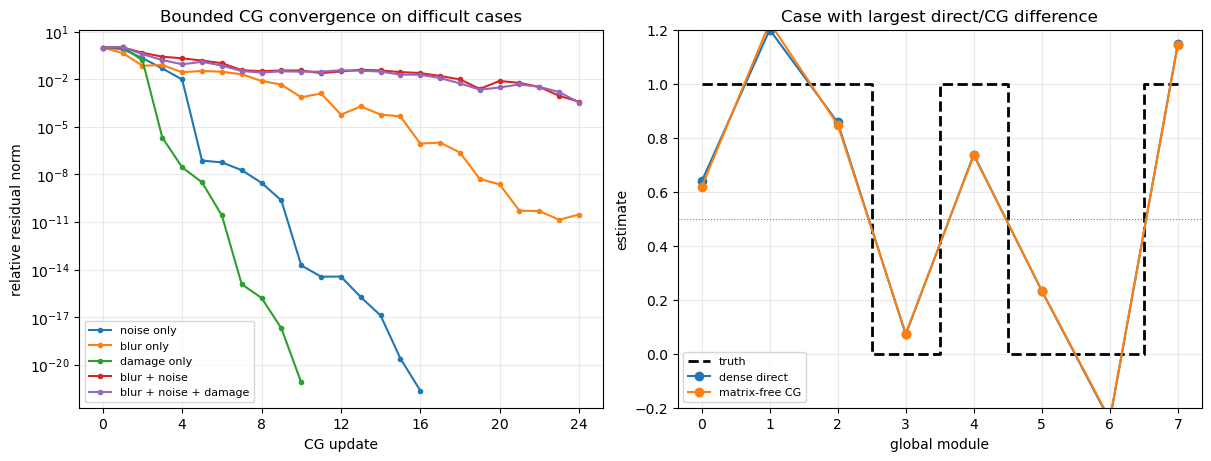

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
gate6_diagnostic_histories = {}

for profile_name, indices in gate5_selected_diagnostics:
    blur_index, noise_index, damage_index, _ = indices
    local_blur = local_blur_for_sigma(gate5_blur_levels[blur_index]).astype(np.float32)
    local_confidence = windowize_scanlines(
        scanline_confidence_for_damage(gate5_damage_widths[damage_index])
    ).reshape(-1).astype(np.float32)
    apply_operator = make_matrix_free_normal_operator(
        local_blur, local_confidence,
        np.float32(gate4_sheaf_strength), np.float32(tikhonov_strength),
    )
    observations = gate5_observations[indices].astype(np.float32)
    right_hand_side = apply_local_observation_transpose(
        local_confidence * observations, local_blur
    )
    _, solver_info = bounded_conjugate_gradient(
        apply_operator, right_hand_side, gate6_iteration_budget
    )
    history = solver_info['relative_residual']
    gate6_diagnostic_histories[profile_name] = history
    axes[0].semilogy(np.arange(len(history)), history, marker='o', markersize=3, label=profile_name)

axes[0].set(title='Bounded CG convergence on difficult cases', xlabel='CG update', ylabel='relative residual norm', xticks=np.arange(0, gate6_iteration_budget + 1, 4))
axes[0].grid(alpha=0.25, which='both')
axes[0].legend(fontsize=8)

largest_difference_indices = np.unravel_index(
    np.argmax(gate6_direct_max_difference), gate6_direct_max_difference.shape
)
largest_difference_truth = gate5_truths[largest_difference_indices]
largest_difference_direct = gate5_estimates[(3,) + largest_difference_indices]
largest_difference_matrix_free = gate6_estimates[largest_difference_indices]
module_positions = np.arange(len(binary_truth))
axes[1].step(module_positions, largest_difference_truth, where='mid', color='black', linestyle='--', linewidth=2, label='truth')
axes[1].plot(module_positions, largest_difference_direct, 'o-', label='dense direct')
axes[1].plot(module_positions, largest_difference_matrix_free, 'o-', label='matrix-free CG')
axes[1].axhline(0.5, color='0.5', linewidth=0.8, linestyle=':')
axes[1].set(title='Case with largest direct/CG difference', xlabel='global module', ylabel='estimate', xticks=module_positions, ylim=(-0.2, 1.2))
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
plt.show()

## Gate 6 conclusion and checkpoint

The local operator is numerically equivalent to the dense sheaf system, and a bounded 24-update `float32` CG solve retains the dense method's aggregate recovery behavior on this experiment. The solver core uses local window operations and a small fixed set of vectors rather than global matrices.

The current Python matrix-free code is expected to be slower than optimized NumPy/LAPACK on a tiny $36\times36$ problem because it executes many interpreted loops. That comparison does not predict optimized C++ performance. Conversely, the reported core bytes do not include image storage, decoder/search state, code, stack overhead, or optional convergence history. Both latency and peak RAM still require measurement in a C++ prototype on target-like hardware.

This completes the planned linear cellular-sheaf foundation at the original eight-module scale. Gate 7 below performs one final length-scaling check before this notebook closes.

# Gate 7: scaling to longer module sequences

The earlier experiments used eight-module sequences so every matrix and signal remained easy to inspect. This final gate keeps the same local construction but increases the global sequence length through powers of two: $8,16,32,64$ modules.

Every case uses three scanlines, four-module windows with two-module overlap, Gaussian blur $\sigma=0.9$ modules, sensor-noise standard deviation $0.12$, and a low-confidence damaged region spanning one eighth of the middle scanline. The matrix-free solver retains its fixed budget of 24 `float32` CG updates. We run 32 seeded trials per length.

This is still a generic binary restoration benchmark, not an EAN-13 or Code 128 decoder. Dense direct solving is retained across this requested length range so its scaling can be compared with the matrix-free path.

> Exact-sequence success becomes progressively stricter with length: one wrong module makes the whole sample unsuccessful. BER and RMSE are therefore the more comparable length-normalized measures. Unlike the earlier gates, every Gate 7 estimate is digitized with its own adaptive two-cluster threshold rather than the fixed value 0.5.

## Adaptive digitization used in Gate 7

For each estimator and each trial, initialize a low center at the minimum restored value and a high center at the maximum. Split the restored module values at the midpoint of those centers, replace each center with the mean of its assigned group, and repeat for at most eight updates or until the centers stop changing. The final threshold is

$$T_{\mathrm{adaptive}}=\frac{\mu_{\mathrm{low}}+\mu_{\mathrm{high}}}{2}.$$

Values below this sample-specific threshold become zero and values at or above it become one. This is lightweight one-dimensional two-means clustering: it learns one global threshold per restored signal, not a spatially varying threshold along the barcode.

In [25]:
gate7_lengths = np.array([8, 16, 32, 64])
gate7_trials_per_length = 32
gate7_seed = 73
gate7_rng = np.random.default_rng(gate7_seed)
gate7_blur_sigma = 0.9
gate7_noise_std = 0.12
gate7_method_names = (
    'raw mean',
    'confidence mean',
    'dense float64 direct',
    'matrix-free float32 CG',
)

def gate7_window_starts(module_count):
    return np.arange(0, module_count - window_width + 1, overlap_width)

def gate7_windowize(scanlines):
    scanlines = np.asarray(scanlines)
    starts = gate7_window_starts(scanlines.shape[-1])
    return np.stack([scanlines[..., start:start + window_width] for start in starts], axis=-2)

def gate7_glue(stalk_values, module_count):
    starts = gate7_window_starts(module_count)
    values = np.asarray(stalk_values).reshape(number_of_scanlines, len(starts), window_width)
    total = np.zeros((number_of_scanlines, module_count), dtype=values.dtype)
    count = np.zeros(module_count, dtype=values.dtype)
    for window_index, start in enumerate(starts):
        total[:, start:start + window_width] += values[:, window_index]
        count[start:start + window_width] += 1
    return total / count

def gate7_apply_observation(stalk_values, local_blur, module_count):
    windows = len(gate7_window_starts(module_count))
    grid = np.asarray(stalk_values).reshape(number_of_scanlines, windows, window_width)
    return np.einsum('ij,abj->abi', local_blur, grid).reshape(-1)

def gate7_apply_observation_transpose(observations, local_blur, module_count):
    windows = len(gate7_window_starts(module_count))
    grid = np.asarray(observations).reshape(number_of_scanlines, windows, window_width)
    return np.einsum('ji,abj->abi', local_blur, grid).reshape(-1)

def gate7_apply_laplacian(stalk_values, module_count):
    windows = len(gate7_window_starts(module_count))
    values = np.asarray(stalk_values).reshape(number_of_scanlines, windows, window_width)
    result = np.zeros_like(values)

    horizontal_disagreement = values[:, 1:, :overlap_width] - values[:, :-1, -overlap_width:]
    result[:, :-1, -overlap_width:] -= horizontal_disagreement
    result[:, 1:, :overlap_width] += horizontal_disagreement

    vertical_disagreement = values[1:] - values[:-1]
    result[:-1] -= vertical_disagreement
    result[1:] += vertical_disagreement
    return result.reshape(-1)

def gate7_make_operator(local_blur, local_confidence, module_count):
    def apply_operator(stalk_values):
        blurred = gate7_apply_observation(stalk_values, local_blur, module_count)
        data_term = gate7_apply_observation_transpose(
            local_confidence * blurred, local_blur, module_count
        )
        return (
            data_term
            + np.float32(gate4_sheaf_strength) * gate7_apply_laplacian(stalk_values, module_count)
            + np.float32(tikhonov_strength) * stalk_values
        )
    return apply_operator

# The generalized vectorized operator must reproduce Gate 6 at N=8.
gate7_check_vector = np.random.default_rng(74).normal(size=variable_count)
gate7_generalization_error = np.max(np.abs(
    gate7_apply_laplacian(gate7_check_vector, 8)
    - apply_local_sheaf_laplacian(gate7_check_vector)
))
print(f'generalized/local Laplacian difference at N=8: {gate7_generalization_error:.3e}')
assert gate7_generalization_error < 1e-12

generalized/local Laplacian difference at N=8: 4.441e-16


In [26]:
def gate7_dense_normal_matrix(module_count, local_blur, local_confidence):
    windows = len(gate7_window_starts(module_count))
    nodes = number_of_scanlines * windows
    variables = nodes * window_width
    normal_matrix = np.zeros((variables, variables), dtype=np.float64)

    confidence_grid = np.asarray(local_confidence).reshape(nodes, window_width)
    for node_index in range(nodes):
        node_slice = slice(node_index * window_width, (node_index + 1) * window_width)
        normal_matrix[node_slice, node_slice] += (
            local_blur.T @ np.diag(confidence_grid[node_index]) @ local_blur
        )

    def add_pair(first, second):
        normal_matrix[first, first] += gate4_sheaf_strength
        normal_matrix[second, second] += gate4_sheaf_strength
        normal_matrix[first, second] -= gate4_sheaf_strength
        normal_matrix[second, first] -= gate4_sheaf_strength

    for scanline_index in range(number_of_scanlines):
        for window_index in range(windows - 1):
            left_node = scanline_index * windows + window_index
            right_node = left_node + 1
            for coordinate in range(overlap_width):
                left = left_node * window_width + window_width - overlap_width + coordinate
                right = right_node * window_width + coordinate
                add_pair(left, right)

    for scanline_index in range(number_of_scanlines - 1):
        for window_index in range(windows):
            upper_node = scanline_index * windows + window_index
            lower_node = upper_node + windows
            for coordinate in range(window_width):
                add_pair(upper_node * window_width + coordinate, lower_node * window_width + coordinate)

    normal_matrix.flat[::variables + 1] += tikhonov_strength
    return normal_matrix

def gate7_random_truth(random_generator, module_count):
    truth = random_generator.integers(0, 2, module_count).astype(np.float32)
    while np.all(truth == truth[0]):
        truth = random_generator.integers(0, 2, module_count).astype(np.float32)
    return truth

def gate7_adaptive_threshold(estimate, maximum_updates=8):
    values = np.asarray(estimate, dtype=np.float64)
    low_center = float(np.min(values))
    high_center = float(np.max(values))
    if np.isclose(low_center, high_center):
        return 0.5 * (low_center + high_center)

    for _ in range(maximum_updates):
        midpoint = 0.5 * (low_center + high_center)
        low_values = values[values < midpoint]
        high_values = values[values >= midpoint]
        if low_values.size == 0 or high_values.size == 0:
            break
        next_low = float(low_values.mean())
        next_high = float(high_values.mean())
        if np.isclose(next_low, low_center) and np.isclose(next_high, high_center):
            low_center, high_center = next_low, next_high
            break
        low_center, high_center = next_low, next_high

    return 0.5 * (low_center + high_center)

gate7_shape = (len(gate7_method_names), len(gate7_lengths), gate7_trials_per_length)
gate7_success = np.full(gate7_shape, np.nan)
gate7_ber = np.full(gate7_shape, np.nan)
gate7_rmse = np.full(gate7_shape, np.nan)
gate7_runtime_us = np.full(gate7_shape, np.nan)
gate7_thresholds = np.full(gate7_shape, np.nan)
gate7_examples = {}

def gate7_store(method_index, length_index, trial_index, estimate, truth, elapsed_ns):
    threshold = gate7_adaptive_threshold(estimate)
    decoded = (np.asarray(estimate) >= threshold).astype(np.int8)
    truth_bits = truth.astype(np.int8)
    target = (method_index, length_index, trial_index)
    gate7_success[target] = np.array_equal(decoded, truth_bits)
    gate7_ber[target] = np.mean(decoded != truth_bits)
    gate7_rmse[target] = np.sqrt(np.mean((np.asarray(estimate) - truth) ** 2))
    gate7_runtime_us[target] = elapsed_ns / 1_000.0
    gate7_thresholds[target] = threshold

gate7_local_blur32 = local_blur_for_sigma(gate7_blur_sigma).astype(np.float32)
gate7_local_blur64 = gate7_local_blur32.astype(np.float64)

for length_index, module_count in enumerate(gate7_lengths):
    module_count = int(module_count)
    damage_width = max(1, module_count // 8)
    damage_start = (module_count - damage_width) // 2
    global_confidence = np.ones((number_of_scanlines, module_count), dtype=np.float32)
    global_confidence[damaged_scanline_index, damage_start:damage_start + damage_width] = 0.02
    local_confidence = gate7_windowize(global_confidence).reshape(-1).astype(np.float32)
    damaged_coordinates = local_confidence < 0.1
    apply_operator = gate7_make_operator(gate7_local_blur32, local_confidence, module_count)

    dense_matrix = gate7_dense_normal_matrix(
        module_count, gate7_local_blur64, local_confidence.astype(np.float64)
    )

    for trial_index in range(gate7_trials_per_length):
        truth = gate7_random_truth(gate7_rng, module_count)
        latent = gate7_windowize(
            np.tile(truth, (number_of_scanlines, 1))
        ).reshape(-1)
        observations = gate7_apply_observation(
            latent, gate7_local_blur32, module_count
        )
        observations += gate7_rng.normal(0.0, gate7_noise_std, observations.size).astype(np.float32)
        observations[damaged_coordinates] = (
            0.5 + gate7_rng.normal(0.0, gate7_noise_std, np.count_nonzero(damaged_coordinates))
        )
        observations = np.clip(observations, 0.0, 1.0)

        started = perf_counter_ns()
        observed_scanlines = gate7_glue(observations, module_count)
        raw_estimate = observed_scanlines.mean(axis=0)
        gate7_store(0, length_index, trial_index, raw_estimate, truth, perf_counter_ns() - started)

        started = perf_counter_ns()
        observed_scanlines = gate7_glue(observations, module_count)
        confidence_estimate = (
            global_confidence * observed_scanlines
        ).sum(axis=0) / global_confidence.sum(axis=0)
        gate7_store(1, length_index, trial_index, confidence_estimate, truth, perf_counter_ns() - started)

        started = perf_counter_ns()
        dense_rhs = gate7_apply_observation_transpose(
            local_confidence.astype(np.float64) * observations,
            gate7_local_blur64, module_count,
        )
        dense_stalks = np.linalg.solve(dense_matrix, dense_rhs)
        dense_estimate = gate7_glue(dense_stalks, module_count).mean(axis=0)
        gate7_store(2, length_index, trial_index, dense_estimate, truth, perf_counter_ns() - started)

        started = perf_counter_ns()
        matrix_free_rhs = gate7_apply_observation_transpose(
            local_confidence * observations, gate7_local_blur32, module_count
        )
        matrix_free_stalks, solver_info = bounded_conjugate_gradient(
            apply_operator, matrix_free_rhs, gate6_iteration_budget
        )
        matrix_free_estimate = gate7_glue(matrix_free_stalks, module_count).mean(axis=0)
        gate7_store(3, length_index, trial_index, matrix_free_estimate, truth, perf_counter_ns() - started)

        if trial_index == 0:
            gate7_examples[module_count] = {
                'truth': truth.copy(),
                'observed_scanlines': observed_scanlines.copy(),
                'raw': raw_estimate.copy(),
                'confidence': confidence_estimate.copy(),
                'dense': dense_estimate.copy(),
                'matrix_free': matrix_free_estimate.copy(),
                'raw_threshold': gate7_thresholds[0, length_index, trial_index],
                'matrix_free_threshold': gate7_thresholds[3, length_index, trial_index],
            }

print(f'random seed: {gate7_seed}')
print(f'trials per length: {gate7_trials_per_length}')
print(f'total generated cases: {len(gate7_lengths) * gate7_trials_per_length}')
assert np.all(np.isfinite(gate7_success))
assert np.all(np.isfinite(gate7_rmse))
assert np.all(np.isfinite(gate7_thresholds))

random seed: 73
trials per length: 32
total generated cases: 128


In [27]:
gate7_summary_shape = gate7_shape[:2]
gate7_mean_success = np.full(gate7_summary_shape, np.nan)
gate7_mean_ber = np.full(gate7_summary_shape, np.nan)
gate7_mean_rmse = np.full(gate7_summary_shape, np.nan)
gate7_median_runtime_us = np.full(gate7_summary_shape, np.nan)
gate7_median_threshold = np.full(gate7_summary_shape, np.nan)
for method_index in range(len(gate7_method_names)):
    for length_index in range(len(gate7_lengths)):
        available = np.isfinite(gate7_success[method_index, length_index])
        if np.any(available):
            gate7_mean_success[method_index, length_index] = gate7_success[method_index, length_index, available].mean()
            gate7_mean_ber[method_index, length_index] = gate7_ber[method_index, length_index, available].mean()
            gate7_mean_rmse[method_index, length_index] = gate7_rmse[method_index, length_index, available].mean()
            gate7_median_runtime_us[method_index, length_index] = np.median(gate7_runtime_us[method_index, length_index, available])
            gate7_median_threshold[method_index, length_index] = np.median(gate7_thresholds[method_index, length_index, available])
gate7_windows = gate7_lengths // 2 - 1
gate7_variables = number_of_scanlines * gate7_windows * window_width
gate7_matrix_free_bytes = (7 * gate7_variables + window_width ** 2) * np.dtype(np.float32).itemsize
gate7_dense_matrix_bytes = gate7_variables ** 2 * np.dtype(np.float64).itemsize

print(f"{'modules':>7s} {'variables':>9s}  {'method':27s} {'threshold':>10s} {'exact':>8s} {'BER':>9s} {'RMSE':>9s} {'median us':>11s}")
print('-' * 99)
for length_index, module_count in enumerate(gate7_lengths):
    for method_index, method_name in enumerate(gate7_method_names):
        if np.isnan(gate7_mean_success[method_index, length_index]):
            result_text = f"{'-':>10s} {'skipped':>8s} {'-':>9s} {'-':>9s} {'-':>11s}"
        else:
            result_text = (
                f'{gate7_median_threshold[method_index, length_index]:10.4f} '
                f'{gate7_mean_success[method_index, length_index]:8.3f} '
                f'{gate7_mean_ber[method_index, length_index]:9.5f} '
                f'{gate7_mean_rmse[method_index, length_index]:9.4f} '
                f'{gate7_median_runtime_us[method_index, length_index]:11.2f}'
            )
        print(
            f'{int(module_count):7d} {int(gate7_variables[length_index]):9d}  '
            f'{method_name:27s} {result_text}'
        )
    print()

print('Memory lower bounds at the largest length:')
print(f'  matrix-free core + confidence + observation: {gate7_matrix_free_bytes[-1] / 1024:.2f} KiB')
print(f'  one dense float64 normal matrix only:         {gate7_dense_matrix_bytes[-1] / 1024**2:.2f} MiB')

assert np.nanmean(gate7_mean_ber[3]) < np.nanmean(gate7_mean_ber[1])
assert gate7_matrix_free_bytes[-1] < 48 * 1024
assert gate7_dense_matrix_bytes[-1] > 1024**2

modules variables  method                       threshold    exact       BER      RMSE   median us
---------------------------------------------------------------------------------------------------
      8        36  raw mean                        0.5194    0.500   0.09766    0.2991       38.37
      8        36  confidence mean                 0.5113    0.531   0.08203    0.2909       31.72
      8        36  dense float64 direct            0.4917    0.969   0.00391    0.1477       75.60
      8        36  matrix-free float32 CG          0.4917    1.000   0.00000    0.1477     1058.64

     16        84  raw mean                        0.4990    0.438   0.05078    0.2832       53.02
     16        84  confidence mean                 0.5000    0.438   0.05273    0.2751       46.40
     16        84  dense float64 direct            0.4956    0.906   0.00781    0.1481      173.77
     16        84  matrix-free float32 CG          0.4958    0.906   0.00781    0.1490     1117.25

     32

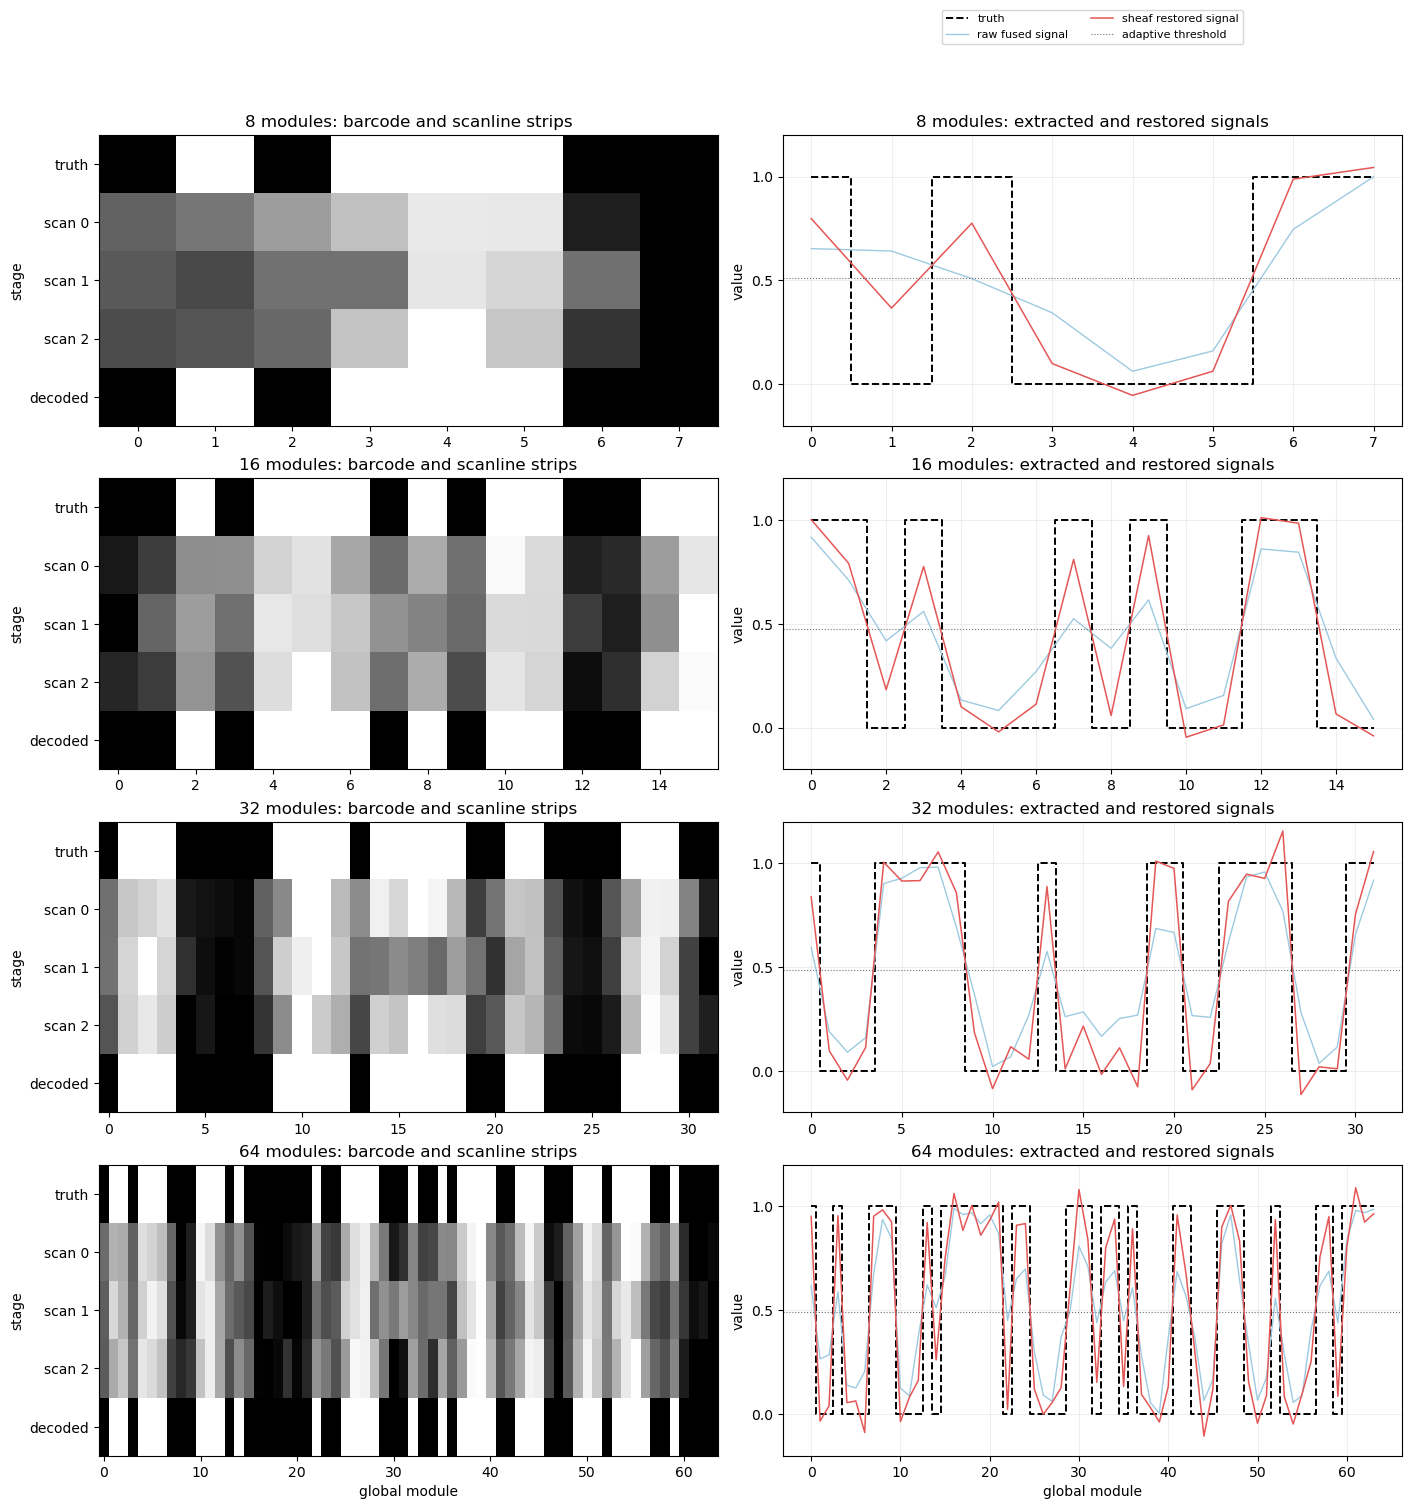

In [28]:
fig, axes = plt.subplots(len(gate7_lengths), 2, figsize=(14, 15), constrained_layout=True)

for row_index, module_count in enumerate(gate7_lengths):
    module_count = int(module_count)
    example = gate7_examples[module_count]
    truth = example['truth']
    restored = example['matrix_free']
    adaptive_threshold = example['matrix_free_threshold']
    digitized = (restored >= adaptive_threshold).astype(float)

    strip_stack = np.vstack([
        truth,
        example['observed_scanlines'],
        digitized,
    ])
    axes[row_index, 0].imshow(
        strip_stack, aspect='auto', interpolation='nearest',
        vmin=0, vmax=1, cmap='gray_r',
    )
    axes[row_index, 0].set(
        title=f'{module_count} modules: barcode and scanline strips',
        ylabel='stage',
        yticks=np.arange(5),
        yticklabels=('truth', 'scan 0', 'scan 1', 'scan 2', 'decoded'),
    )

    positions = np.arange(module_count)
    axes[row_index, 1].step(
        positions, truth, where='mid', color='black', linewidth=1.4,
        linestyle='--', label='truth',
    )
    axes[row_index, 1].plot(positions, example['raw'], color='#9ECAE1', linewidth=1.0, label='raw fused signal')
    axes[row_index, 1].plot(positions, restored, color='#E45756', linewidth=1.1, label='sheaf restored signal')
    axes[row_index, 1].axhline(adaptive_threshold, color='0.45', linewidth=0.8, linestyle=':', label='adaptive threshold')
    axes[row_index, 1].set(
        title=f'{module_count} modules: extracted and restored signals',
        ylabel='value', ylim=(-0.2, 1.2), yticks=(0.0, 0.5, 1.0),
    )
    axes[row_index, 1].grid(alpha=0.2)

axes[-1, 0].set_xlabel('global module')
axes[-1, 1].set_xlabel('global module')
axes[0, 1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.45), ncol=2, fontsize=8)
plt.show()

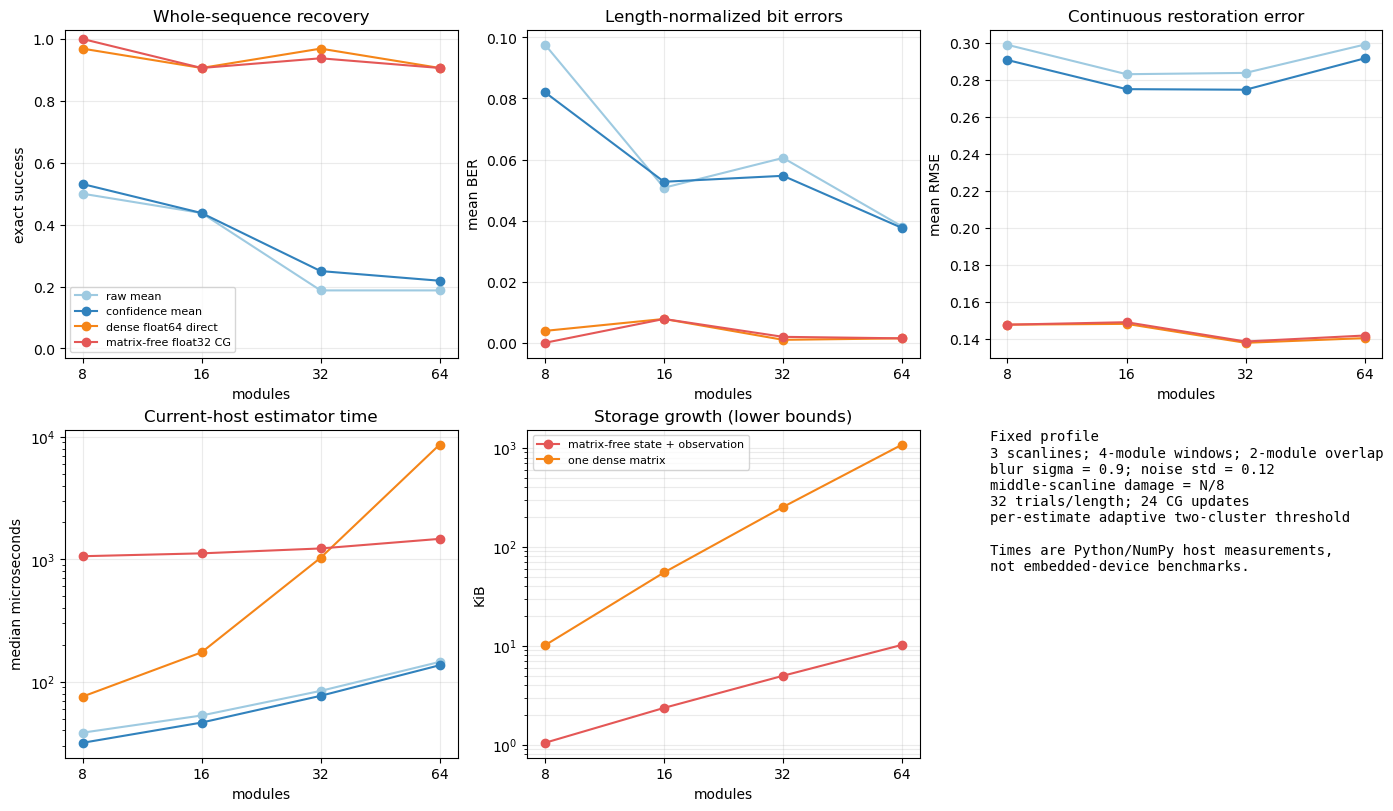

In [29]:
gate7_colors = ('#9ECAE1', '#3182BD', '#F58518', '#E45756')
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for method_index, (method_name, color) in enumerate(zip(gate7_method_names, gate7_colors)):
    available = np.isfinite(gate7_mean_success[method_index])
    axes[0, 0].plot(gate7_lengths[available], gate7_mean_success[method_index, available], 'o-', color=color, label=method_name)
    axes[0, 1].plot(gate7_lengths[available], gate7_mean_ber[method_index, available], 'o-', color=color, label=method_name)
    axes[0, 2].plot(gate7_lengths[available], gate7_mean_rmse[method_index, available], 'o-', color=color, label=method_name)
    axes[1, 0].plot(gate7_lengths[available], gate7_median_runtime_us[method_index, available], 'o-', color=color, label=method_name)

for ax in axes.flat[:4]:
    ax.set_xscale('log', base=2)
    ax.set_xticks(gate7_lengths, labels=gate7_lengths)
    ax.grid(alpha=0.25)
axes[0, 0].set(title='Whole-sequence recovery', xlabel='modules', ylabel='exact success', ylim=(-0.03, 1.03))
axes[0, 1].set(title='Length-normalized bit errors', xlabel='modules', ylabel='mean BER')
axes[0, 2].set(title='Continuous restoration error', xlabel='modules', ylabel='mean RMSE')
axes[1, 0].set(title='Current-host estimator time', xlabel='modules', ylabel='median microseconds', yscale='log')
axes[0, 0].legend(fontsize=8)

axes[1, 1].plot(gate7_lengths, gate7_matrix_free_bytes / 1024, 'o-', color='#E45756', label='matrix-free state + observation')
axes[1, 1].plot(gate7_lengths, gate7_dense_matrix_bytes / 1024, 'o-', color='#F58518', label='one dense matrix')
axes[1, 1].set_xscale('log', base=2)
axes[1, 1].set_yscale('log')
axes[1, 1].set(title='Storage growth (lower bounds)', xlabel='modules', ylabel='KiB', xticks=gate7_lengths, xticklabels=gate7_lengths)
axes[1, 1].grid(alpha=0.25, which='both')
axes[1, 1].legend(fontsize=8)

axes[1, 2].axis('off')
axes[1, 2].text(
    0.0, 1.0,
    'Fixed profile\n'
    f'3 scanlines; 4-module windows; 2-module overlap\n'
    f'blur sigma = {gate7_blur_sigma}; noise std = {gate7_noise_std}\n'
    'middle-scanline damage = N/8\n'
    f'{gate7_trials_per_length} trials/length; {gate6_iteration_budget} CG updates\n'
    'per-estimate adaptive two-cluster threshold\n\n'
    'Times are Python/NumPy host measurements,\nnot embedded-device benchmarks.',
    va='top', family='monospace', fontsize=10,
)
plt.show()

## Gate 7 conclusion and checkpoint

The length sweep tests whether the same local model remains useful when the global sequence is no longer a toy-sized eight modules. Exact-sequence success must be read alongside BER: if the per-module error probability stays fixed, longer sequences still become less likely to contain zero errors. Gate 7 digitization learns low- and high-signal cluster centers independently for every estimate and thresholds at their midpoint; it does not assume that the observed midpoint is exactly 0.5.

The matrix-free storage estimate grows linearly because the local window width, overlap, scanline count, and CG buffer count remain fixed. A materialized dense normal matrix grows quadratically. The timings are measurements of this transparent Python implementation on the current host; they show scaling behavior, not target-microcontroller latency.

This now closes Gate 7 and the current linear cellular-sheaf work. Stop here for review and additional ideas; no discrete-sheaf notebook is started automatically.